In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
 
print("✅ Library berhasil di-import")

✅ Library berhasil di-import


In [2]:
PATH = "/kaggle/input/datasets/bintangryan/original-emscad/fake_job_postings.csv"
 
df_raw = pd.read_csv(PATH)
print(f"Shape dataset: {df_raw.shape}")
print(f"\nKolom: {df_raw.columns.tolist()}")
print(f"\nDistribusi label:")

vc = df_raw['fraudulent'].value_counts()
print(f"  Total Data : {len(df_raw):,}")
print(f"  Fraud      : {vc[1]:,} ({vc[1]/len(df_raw)*100:.2f}%)")
print(f"  Non-Fraud  : {vc[0]:,} ({vc[0]/len(df_raw)*100:.2f}%)")
print(f"\nSample data:")
df_raw.head(3)

Shape dataset: (17880, 18)

Kolom: ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Distribusi label:
  Total Data : 17,880
  Fraud      : 866 (4.84%)
  Non-Fraud  : 17,014 (95.16%)

Sample data:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


In [3]:
def missing_stats(data, label_name):
    missing = data.isnull().sum()
    missing_percent = (missing / len(data)) * 100

    return pd.DataFrame({
        f"{label_name} Missing Count": missing,
        f"{label_name} Missing %": missing_percent
    })

# Global
global_stats = missing_stats(df_raw, "Global")
# Fraud = 0
fraud_0_stats = missing_stats(df_raw[df_raw['fraudulent'] == 0], "Fraud=0")
# Fraud = 1
fraud_1_stats = missing_stats(df_raw[df_raw['fraudulent'] == 1], "Fraud=1")

final_missing = pd.concat([global_stats, fraud_0_stats, fraud_1_stats], axis=1)
final_missing = final_missing.sort_values(by="Global Missing Count", ascending=False)

display(final_missing)

,Global Missing Count,Global Missing %,Fraud=0 Missing Count,Fraud=0 Missing %,Fraud=1 Missing Count,Fraud=1 Missing %
salary_range,15012,83.9597,14369,84.4540,643,74.2494
department,11547,64.5805,11016,64.7467,531,61.3164
required_education,8105,45.3300,7654,44.9865,451,52.0785
benefits,7212,40.3356,6848,40.2492,364,42.0323
required_experience,7050,39.4295,6615,38.8797,435,50.2309
function,6455,36.1018,6118,35.9586,337,38.9145
industry,4903,27.4217,4628,27.2011,275,31.7552
employment_type,3471,19.4128,3230,18.9844,241,27.8291
company_profile,3308,18.5011,2721,15.9927,587,67.7829
requirements,2696,15.0783,2542,14.9406,154,17.7829


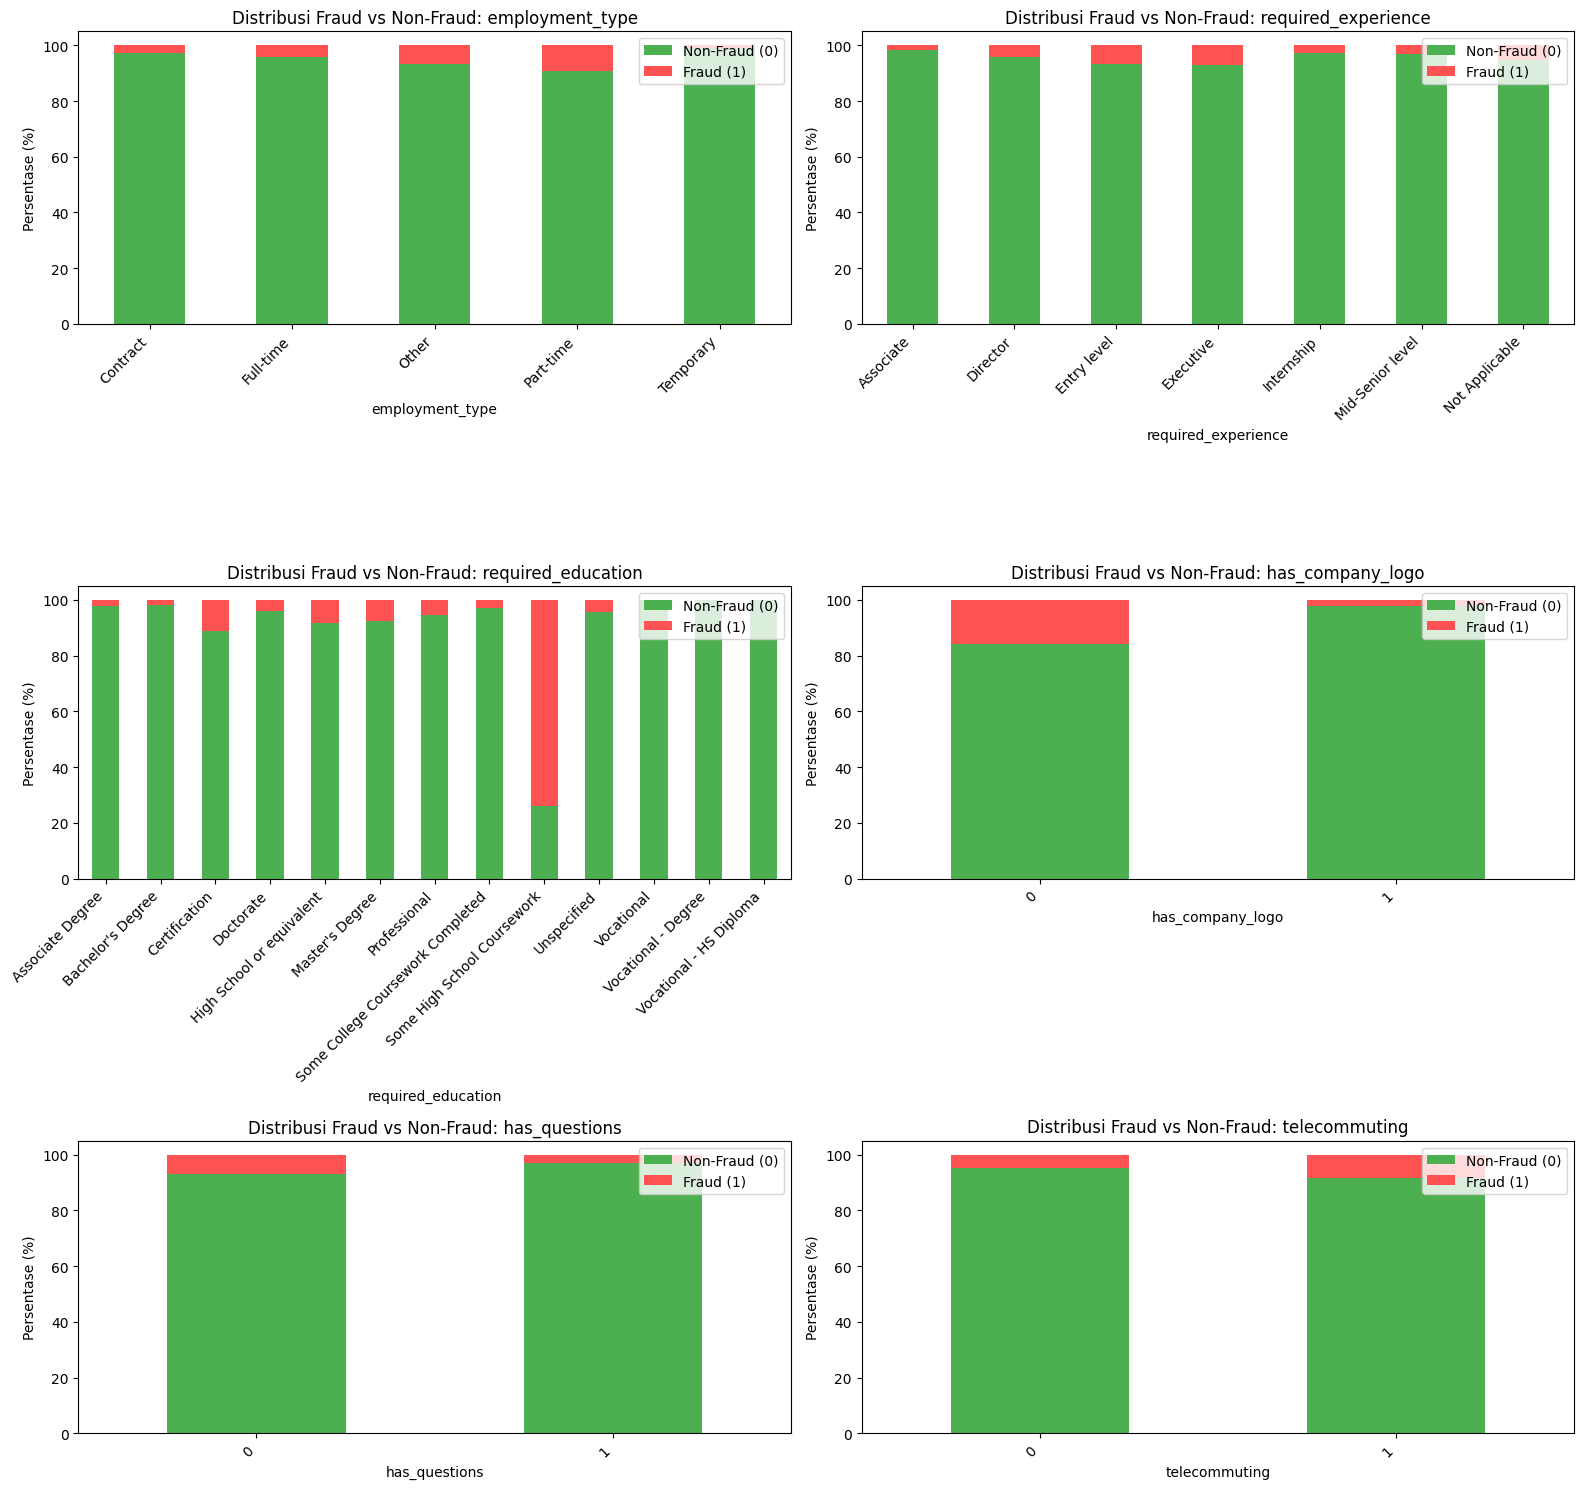


--- TABEL PERSENTASE FRAUD PER KATEGORI ---

Persentase Fraud pada kolom 'employment_type':


fraudulent,% Fraud Cases
employment_type,
Part-time,9.2848
Other,6.6079
Full-time,4.2169
Contract,2.8871
Temporary,0.8299



Persentase Fraud pada kolom 'required_experience':


fraudulent,% Fraud Cases
required_experience,
Executive,7.0922
Entry level,6.6370
Not Applicable,5.3763
Director,4.3702
Mid-Senior level,2.9667
Internship,2.6247
Associate,1.8285



Persentase Fraud pada kolom 'required_education':


...

fraudulent,% Fraud Cases
has_company_logo,
0,15.9290
1,1.9902



Persentase Fraud pada kolom 'has_questions':


fraudulent,% Fraud Cases
has_questions,
0,6.7782
1,2.8435



Persentase Fraud pada kolom 'telecommuting':


fraudulent,% Fraud Cases
telecommuting,
1,8.3442
0,4.6865


In [4]:
# 1. Identifikasi kolom kategorikal
categorical_cols = [
    'employment_type', 'required_experience', 'required_education',
    'has_company_logo', 'has_questions', 'telecommuting'
]

# 2. Setup plotting
n_cols = 2
n_rows = (len(categorical_cols) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

# 3. Looping untuk setiap kolom
for i, col in enumerate(categorical_cols):
    temp_df = df_raw.groupby(col)['fraudulent'].value_counts(normalize=True).unstack().fillna(0) * 100
    temp_df.plot(kind='bar', stacked=True, ax=axes[i], color=['#4CAF50', '#FF5252'])
    axes[i].set_title(f'Distribusi Fraud vs Non-Fraud: {col}')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].set_xlabel(col)
    axes[i].legend(['Non-Fraud (0)', 'Fraud (1)'], loc='upper right')
    plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 4. Menampilkan Tabel 
print("\n--- TABEL PERSENTASE FRAUD PER KATEGORI ---")
for col in categorical_cols:
    # Menghitung berapa persen fraud di setiap fitur kategorikal
    pivot = pd.crosstab(df_raw[col], df_raw['fraudulent'], normalize='index') * 100
    print(f"\nPersentase Fraud pada kolom '{col}':")
    display(pivot[[1]].sort_values(by=1, ascending=False).rename(columns={1: '% Fraud Cases'}))

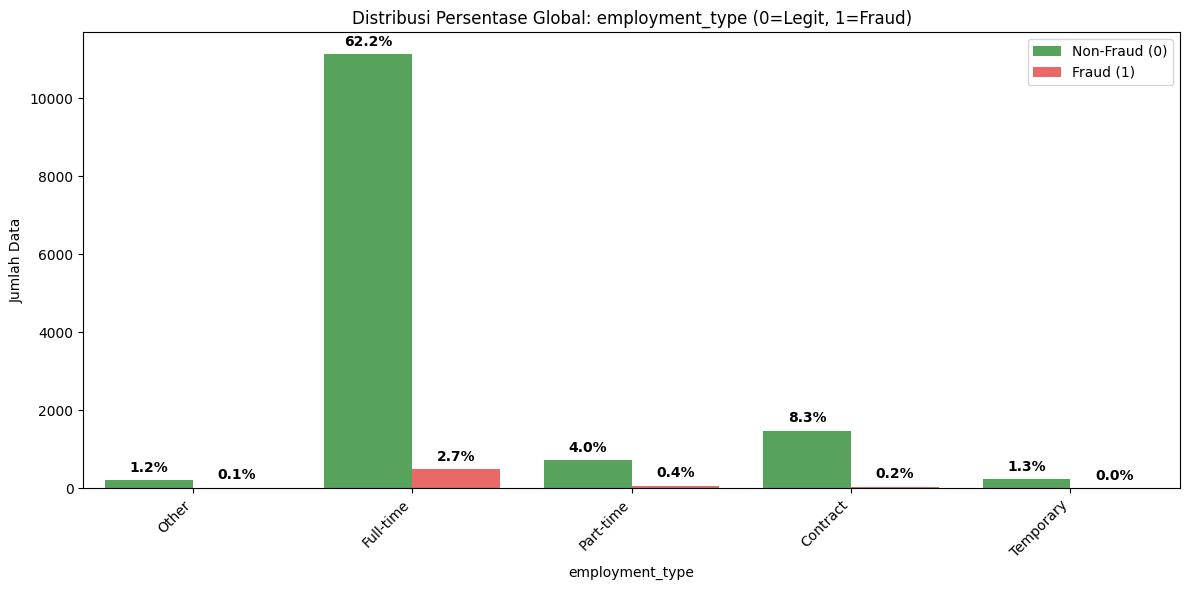

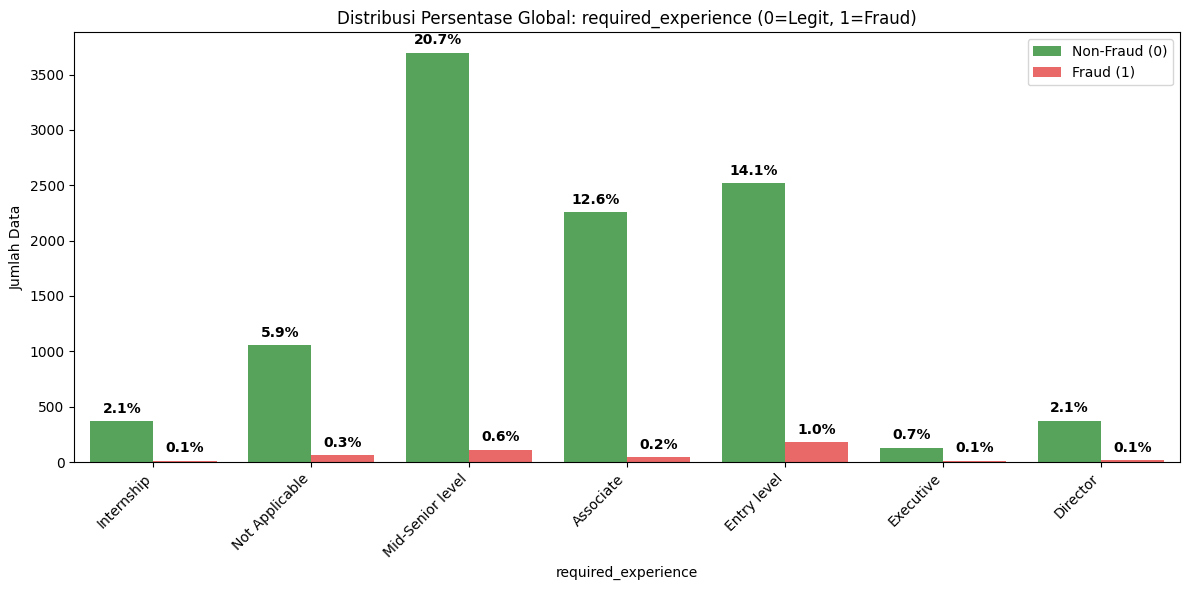

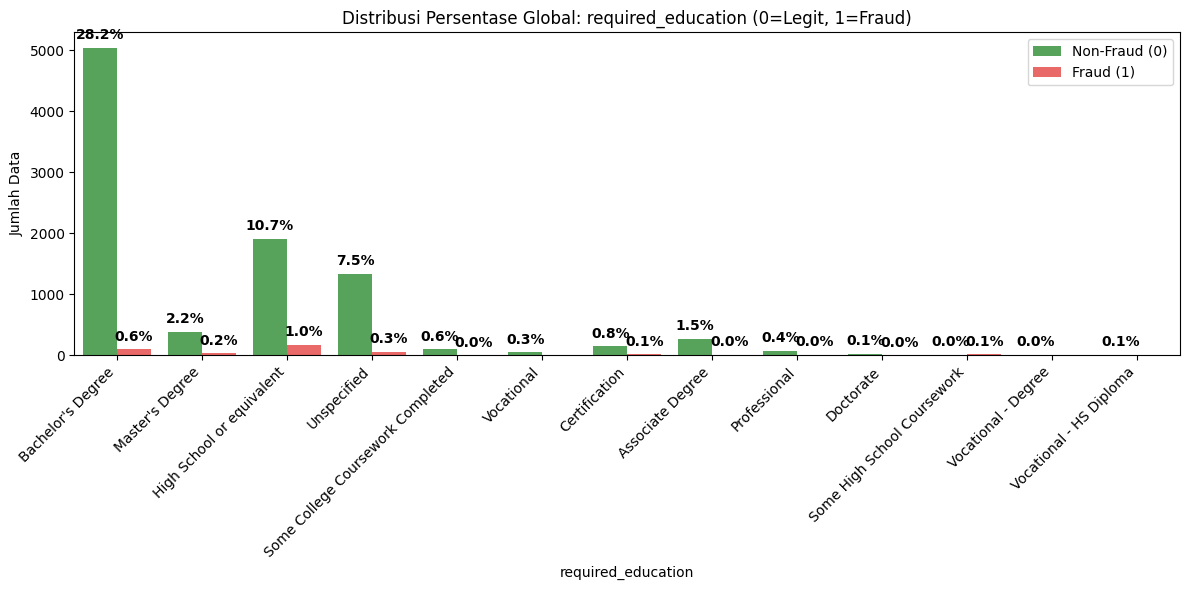

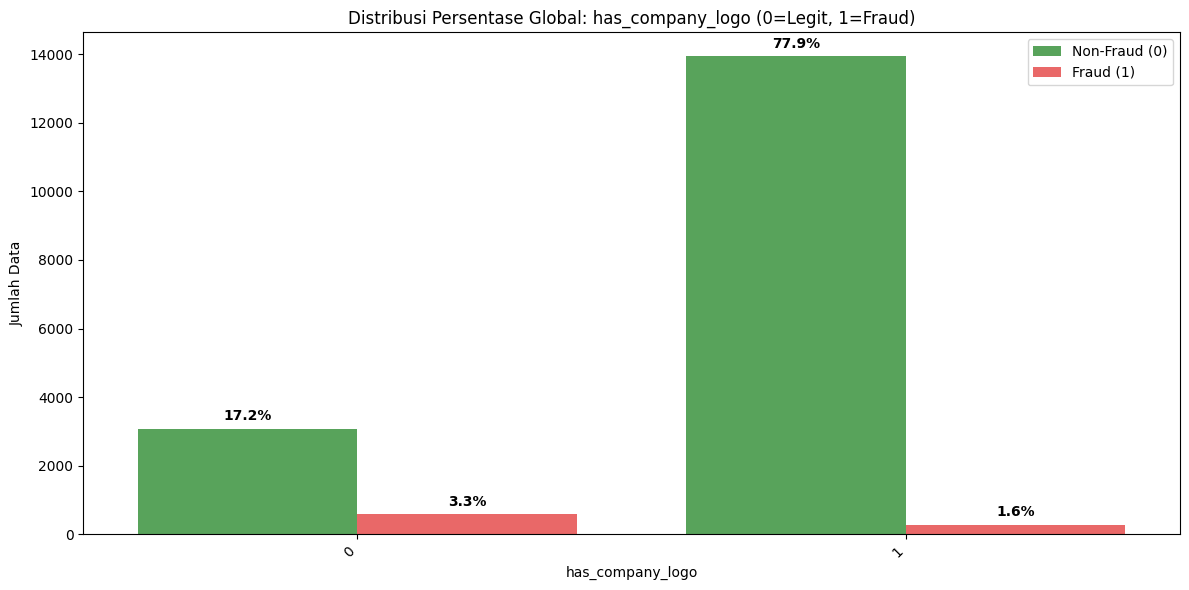

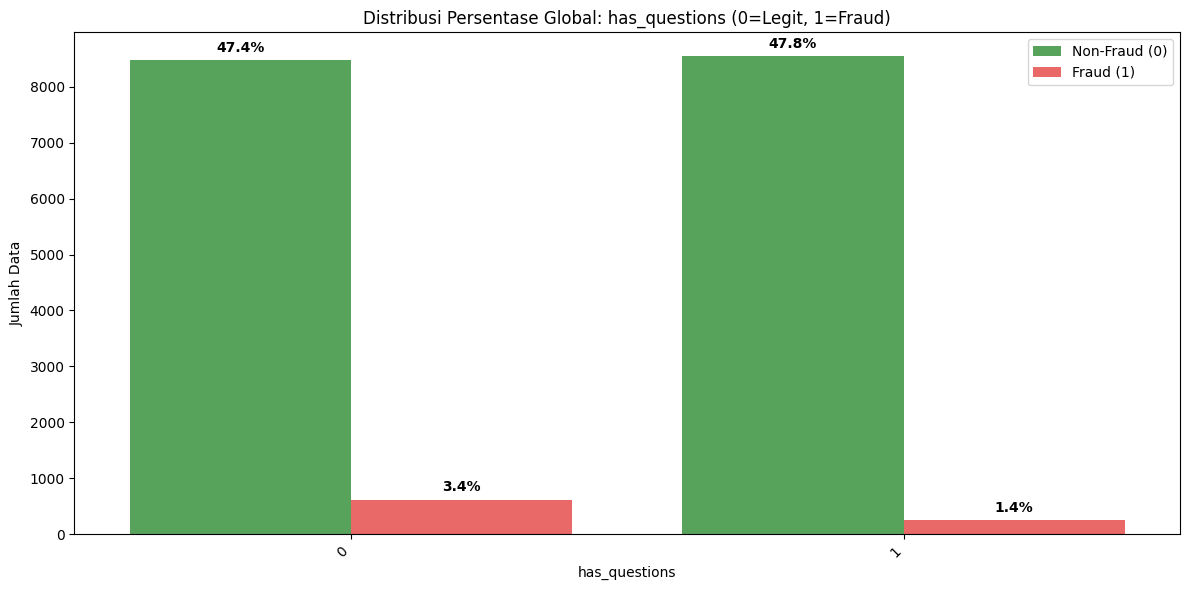

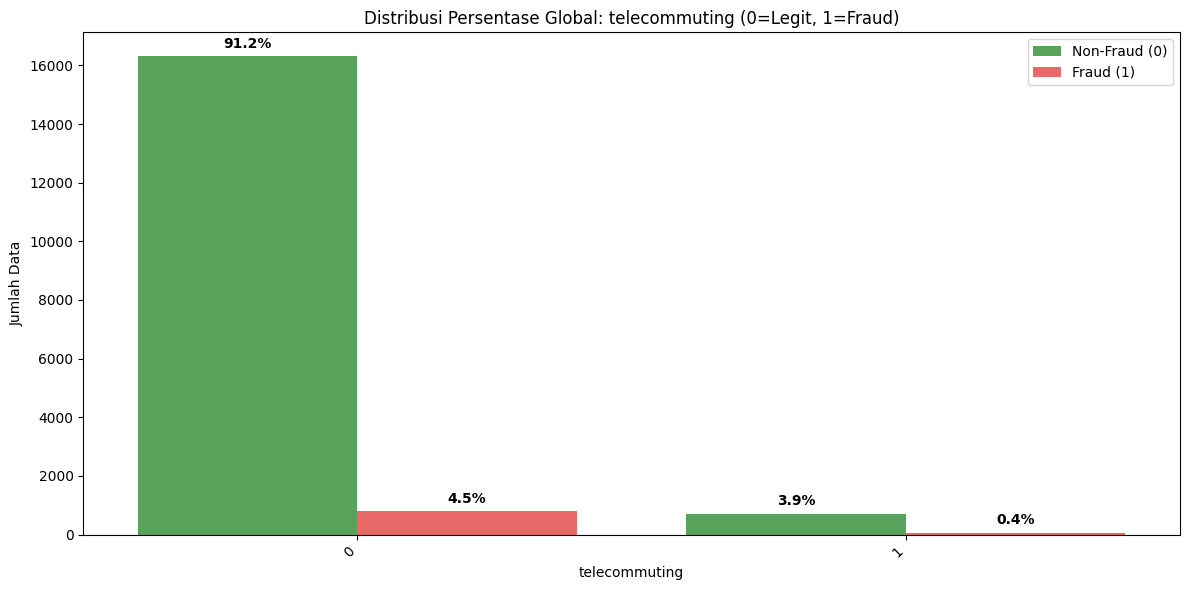

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Plotting dengan Persentase
for col in categorical_cols:
    plt.figure(figsize=(12, 6))

    # Hitung distribusi frekuensi
    ax = sns.countplot(x=col, hue='fraudulent', data=df_raw, palette=['#4CAF50', '#FF5252'])

    # Menghitung total per kategori untuk label persen
    total_data = len(df_raw)

    # Menambahkan label persen di atas setiap bar
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            percentage = '{:.1f}%'.format(100 * height / total_data)
            ax.annotate(percentage,
                        (p.get_x() + p.get_width() / 2., height),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points',
                        fontsize=10, fontweight='bold')

    plt.title(f'Distribusi Persentase Global: {col} (0=Legit, 1=Fraud)')
    plt.ylabel('Jumlah Data')
    plt.xticks(rotation=45, ha='right')
    plt.legend(['Non-Fraud (0)', 'Fraud (1)'], loc='upper right')
    plt.tight_layout()
    plt.show()


In [8]:
import re
from bs4 import BeautifulSoup
import pandas as pd

pd.set_option("display.max_colwidth", None)

# 1. Copy data asli
df_clean = df_raw.copy()
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits",
]


# 2. Fungsi pembersih teks
def clean_text(text):
    if pd.isna(text) or text == "":
        return ""
    text = BeautifulSoup(str(text), "html.parser").get_text()
    text = re.sub(r"([a-z])([A-Z])", r"\1 \2", text)
    text = re.sub(r"([.,!?:])([a-zA-Z0-9])", r"\1 \2", text)
    text = re.sub(
        r"#?URL[_\s]*[a-zA-Z0-9]{15,}#?", " ", text, flags=re.IGNORECASE
    )
    text = re.sub(r"[a-zA-Z0-9]{15,}", " ", text)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s.,!?:']", " ", text)
    return re.sub(r"\s+", " ", text).strip().lower()

for col in text_columns:
    df_clean[col] = df_clean[col].fillna("").apply(clean_text)

df_clean["all_text_cleaned"] = df_clean[text_columns].agg(" ".join, axis=1)
df_clean.head()

job_id                                    title            location  \
0       1                         marketing intern    US, NY, New York   
1       2  customer service cloud video production      NZ, , Auckland   
2       3    commissioning machinery assistant cma       US, IA, Wever   
3       4          account executive washington dc  US, DC, Washington   
4       5                      bill review manager  US, FL, Fort Worth   

  department salary_range  \
0  Marketing          NaN   
1    Success          NaN   
2        NaN          NaN   
3      Sales          NaN   
4        NaN          NaN   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          company_profile  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                we're food52, and we've created a groundbreaking and award winning cooking site. we support, connect, and celebrate home cooks, and give them everything they need in one place. we have a top editorial, business, and engineering team. we're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. we attract the most talented home cooks and contributors in the country we also publish well known professionals like mario batali, gwyneth paltrow, and danny meyer. and we have partnerships with whole foods market and random house. food52 has been named the best food website by the james beard foundation and iacp, and has been featured in the new york times, npr, pando daily, tech crunch, and on the today show. we're located in chelsea, in new york city.   
1                                                                                                                                                                                                                                                            

In [9]:
import pandas as pd
from IPython.display import display

def cek_before_after_by_index(idx, df_raw, df_clean, text_cols):
    """
    Menampilkan perbandingan Before (Raw) dan After (Cleaned) 
    secara berdampingan berdasarkan index.
    """
    # Cek apakah index ada di dataframe
    if idx not in df_raw.index or idx not in df_clean.index:
        print(f"Error: Index {idx} tidak ditemukan di DataFrame.")
        return
        
    print("=" * 80)
    print(f"INSPEKSI BEFORE-AFTER | INDEX: {idx}")
    print("=" * 80)
    
    # Gabungkan baris BEFORE dan AFTER ke dalam satu DataFrame baru
    df_compare = pd.DataFrame({
        "BEFORE (Raw Data)": df_raw.loc[idx, text_cols],
        "AFTER (Cleaned Data)": df_clean.loc[idx, text_cols]
    })
    
    # Supaya teks panjang tidak terpotong (opsional jika belum diset di awal)
    pd.set_option("display.max_colwidth", None)
    
    display(df_compare)

# ==========================================
# CARA PAKAINYA:
# ==========================================
# Ganti angka 5 dengan index berapapun yang ingin dilihat
cek_before_after_by_index(5, df_raw, df_clean, text_columns)

INSPEKSI BEFORE-AFTER | INDEX: 5


,BEFORE (Raw Data),AFTER (Cleaned Data)
title,Accounting Clerk,accounting clerk
company_profile,NaN,
description,"Job OverviewApex is an environmental consulting firm that offers stable leadership and growth and views employees as valuable resources. We are seeking a self-motivated, multi-faceted Accounts Payable Clerk to join our team in Rockville, MD and become an integral part of our continued success story. This position entails processing high volume of invoices and working in a fast pace environment; keying and verifying various types of invoices to General Ledger accounts and job numbers submitted by vendors and company personnel; and calculating balance due to vendor by reviewing history of prior payments made to an account. Candidate must be able to answer vendor and personnel inquiries via phone or email. QualificationsThis position requires a high school diploma and 2-5 years of relevant work experience; keen attention to detail; knowledge of commonly-used concepts, practices, and procedures within the accounting field; experience with accounting software; proficiency in MS Office Suite including advanced Excel experience; and a high degree of professionalism.Want to join a team of talented accounting professionals, engineers, and managers? Submit your resume for consideration today!#URL_f030e16ff4531e87a62857357985e3e8f1fdedb40dbfebfeb0e7e3a5ead65097#About ApexApex is a customer-focused company that delivers environmental, health, safety and engineering services to over 700 clients across the United States and abroad. Driven by an entrepreneurial spirit and a dedication to providing responsive, cost-effective solutions, Apex has grown rapidly since our founding in 1988.Working in partnership with our public and private sector clients, our team of experts provides services tailored to support each customer’s unique goals and objectives. By blending strong technical skills, business acumen, and superior customer service, we are able to deliver creative solutions that deliver high quality results at low cost.From commercial and industrial firms to construction, petroleum, and utility companies to financial institutions and government clients, Apex has extensive experience in a wide variety of industries. Our corporate professional resume includes proven capabilities in the areas of water resources, remediation and restoration, assessment and compliance, and industrial hygiene, among others.Ranked in the Top 200 Environmental Firms by ENR Magazine, ranked among the Top 500 Design Firms by ENR Magazine, awarded the 2011 National Environmental Excellence Award for Environmental Stewardship by the National Association of Environmental Professionals, and selected as a 2010 Hot Firm by the Zweig Letter, come join our award winning team.Apex is an entrepreneurial firm, and ensuring that our senior managers are able to move unencumbered is our priority. We are a successful and growing mid-sized firm. We’re small enough that our employees still have access to our leadership, and it’s easy for high-performers to be recognized for their contributions and advance without bureaucracy. With over 30 office locations, we’re big enough to provide comprehensive environmental consulting and engineering services to our diverse client base and to provide resources to our employees to help in their professional development. We offer incentive bonus plans and ownership opportunities for our successful managers.Apex Companies, LLC is an Affirmative Action/Equal Opportunity Employer","job overview apex is an environmental consulting firm that offers stable leadership and growth and views employees as valuable resources. we are seeking a self motivated, multi faceted accounts payable clerk to join our team in rockville, md and become an integral part of our continued success story. this position entails processing high volume of invoices and working in a fast pace environment keying and verifying various types of invoices to general ledger acc

In [7]:
# 1. Fungsi hitung missing value per kategori (Format andalan kamu)
def get_missing_comparison(data_frame, title_label):
    global_stats = data_frame.isnull().sum()
    global_pct = (global_stats / len(data_frame)) * 100

    fraud_0 = data_frame[data_frame['fraudulent'] == 0].isnull().sum()
    fraud_0_pct = (fraud_0 / len(data_frame[data_frame['fraudulent'] == 0])) * 100

    fraud_1 = data_frame[data_frame['fraudulent'] == 1].isnull().sum()
    fraud_1_pct = (fraud_1 / len(data_frame[data_frame['fraudulent'] == 1])) * 100

    df_res = pd.DataFrame({
        'Global Missing': global_stats, 'Global %': global_pct,
        'Legit Missing (0)': fraud_0, 'Legit % (0)': fraud_0_pct,
        'Fraud Missing (1)': fraud_1, 'Fraud % (1)': fraud_1_pct
    }).sort_values(by="Global Missing", ascending=False)

    print(f"\n--- STATISTIK MISSING VALUE: {title_label} ---")
    display(df_res.round(2))

# 2. TAMPILKAN DISTRIBUSI & MISSING VALUE SEBELUM DEDUP
print("="*60)
print(f"ANALISIS DATA SEBELUM DEDUP (Shape Awal: {df_clean.shape})")
print("="*60)
print("Distribusi Kelas Target (Sebelum Dedup):")
print(df_clean['fraudulent'].value_counts())
get_missing_comparison(df_clean, "SEBELUM REMOVE DUPLICATE (BEFORE)")

# 3. PROSES REMOVE DUPLICATE (DEDUP)
print("\n" + "="*60)
print("PROSES REMOVE DUPLICATE SEDANG BERJALAN...")
print("="*60)
df_clean = df_clean.drop_duplicates(subset=['all_text_cleaned'], keep='first')

# 4. TAMPILKAN DISTRIBUSI & MISSING VALUE SETELAH DEDUP
print(f"Shape Akhir Setelah Dedup: {df_clean.shape}")
print("\nDistribusi Kelas Target (Setelah Dedup):")
print(df_clean['fraudulent'].value_counts())
get_missing_comparison(df_clean, "SETELAH REMOVE DUPLICATE (AFTER)")

ANALISIS DATA SEBELUM DEDUP (Shape Awal: (17880, 19))
Distribusi Kelas Target (Sebelum Dedup):
fraudulent
0    17014
1      866
Name: count, dtype: int64

--- STATISTIK MISSING VALUE: SEBELUM REMOVE DUPLICATE (BEFORE) ---


,Global Missing,Global %,Legit Missing (0),Legit % (0),Fraud Missing (1),Fraud % (1)
salary_range,15012,83.9600,14369,84.4500,643,74.2500
department,11547,64.5800,11016,64.7500,531,61.3200
required_education,8105,45.3300,7654,44.9900,451,52.0800
required_experience,7050,39.4300,6615,38.8800,435,50.2300
function,6455,36.1000,6118,35.9600,337,38.9100
industry,4903,27.4200,4628,27.2000,275,31.7600
employment_type,3471,19.4100,3230,18.9800,241,27.8300
location,346,1.9400,327,1.9200,19,2.1900
job_id,0,0.0000,0,0.0000,0,0.0000
title,0,0.0000,0,0.0000,0,0.0000



PROSES REMOVE DUPLICATE SEDANG BERJALAN...
Shape Akhir Setelah Dedup: (15766, 19)

Distribusi Kelas Target (Setelah Dedup):
fraudulent
0    15055
1      711
Name: count, dtype: int64

--- STATISTIK MISSING VALUE: SETELAH REMOVE DUPLICATE (AFTER) ---


,Global Missing,Global %,Legit Missing (0),Legit % (0),Fraud Missing (1),Fraud % (1)
salary_range,13077,82.9400,12559,83.4200,518,72.8600
department,9678,61.3900,9252,61.4500,426,59.9200
required_education,7284,46.2000,6935,46.0600,349,49.0900
required_experience,5793,36.7400,5457,36.2500,336,47.2600
function,5287,33.5300,5043,33.5000,244,34.3200
industry,4408,27.9600,4198,27.8800,210,29.5400
employment_type,3161,20.0500,2997,19.9100,164,23.0700
location,335,2.1200,319,2.1200,16,2.2500
job_id,0,0.0000,0,0.0000,0,0.0000
title,0,0.0000,0,0.0000,0,0.0000


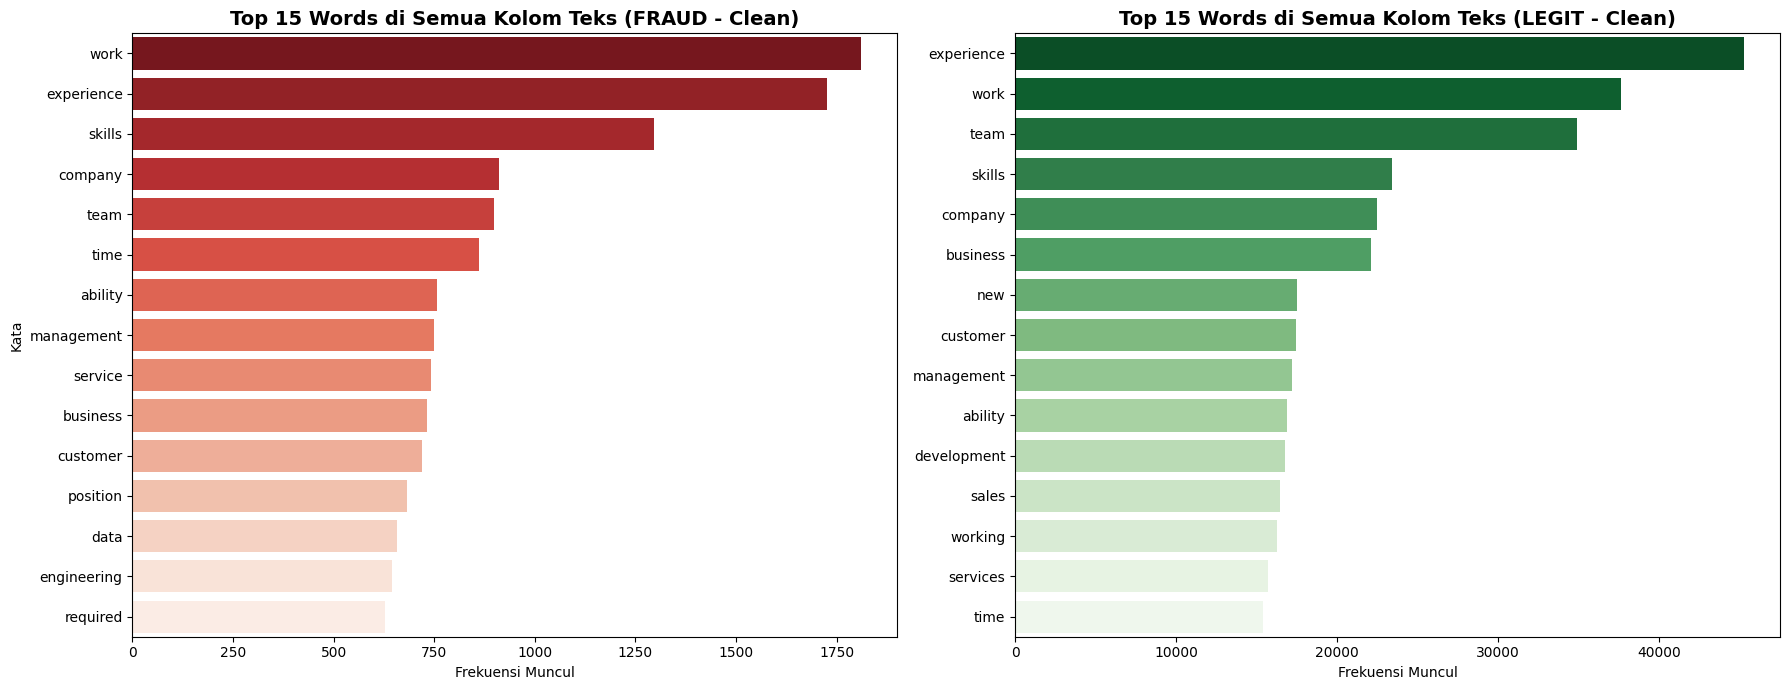

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# ==========================================
# 3. FUNGSI TOP WORDS (MURNI STOP WORDS ENGLISH)
# ==========================================
def get_top_words(corpus, n=15):
    # stop_words langsung diisi 'english' bawaan scikit-learn, apa adanya
    vec = CountVectorizer(stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:n], columns=['Word', 'Frequency'])

# ==========================================
# 4. EKSTRAKSI TOP WORDS (MENGGUNAKAN KOLOM ALL_TEXT_CLEANED)
# ==========================================
# Memisahkan korpus teks berdasarkan target dari df_clean
fraud_corpus_clean = df_clean[df_clean['fraudulent'] == 1]['all_text_cleaned']
legit_corpus_clean = df_clean[df_clean['fraudulent'] == 0]['all_text_cleaned']

# Hitung top 15 words dari masing-masing kelas target
top_fraud_clean = get_top_words(fraud_corpus_clean, n=15)
top_legit_clean = get_top_words(legit_corpus_clean, n=15)

# ==========================================
# 5. VISUALISASI GRAPH BAR SIDE-BY-SIDE
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot Top Words Fraud
sns.barplot(x='Frequency', y='Word', data=top_fraud_clean, ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 15 Words di Semua Kolom Teks (FRAUD - Clean)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frekuensi Muncul')
axes[0].set_ylabel('Kata')

# Plot Top Words Legit
sns.barplot(x='Frequency', y='Word', data=top_legit_clean, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 15 Words di Semua Kolom Teks (LEGIT - Clean)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frekuensi Muncul')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [11]:
fraud = df_clean[df_clean['fraudulent'] == 1]
non_fraud = df_clean[df_clean['fraudulent'] == 0]

# non fraud = 5x fraud
n_fraud = len(fraud)
n_non_fraud = min(len(non_fraud), 5 * n_fraud)

non_fraud_sampled = non_fraud.sample(n=n_non_fraud, random_state=42)

df_balanced = pd.concat([fraud, non_fraud_sampled])
df_balanced = df_balanced.sample(frac=1, random_state=42)  # shuffle

print("After undersampling:")
print(df_balanced['fraudulent'].value_counts())

After undersampling:
fraudulent
0    4330
1     866
Name: count, dtype: int64


=== ANALISIS STATISTIK PANJANG TEKS PER KATEGORI ===

--- Statistik Kolom: TITLE ---
              count    mean     std     50%      max
Real (0)  4330.0000 27.7801 13.2655 25.0000 105.0000
Fraud (1)  866.0000 29.8106 14.9809 27.0000 140.0000

--- Statistik Kolom: COMPANY_PROFILE ---
              count     mean      std      50%       max
Real (0)  4330.0000 609.4397 544.8109 556.0000 5574.0000
Fraud (1)  866.0000 213.5727 356.9879   0.0000 1429.0000

--- Statistik Kolom: DESCRIPTION ---
              count      mean      std      50%        max
Real (0)  4330.0000 1148.6693 836.9415 977.5000 14435.0000
Fraud (1)  866.0000 1101.9688 968.4617 802.0000  8291.0000

--- Statistik Kolom: REQUIREMENTS ---
              count     mean      std      50%       max
Real (0)  4330.0000 586.9827 587.8918 473.0000 6287.0000
Fraud (1)  866.0000 432.1559 552.3355 243.0000 3938.0000

--- Statistik Kolom: BENEFITS ---
              count     mean      std     50%       max
Real (0)  4330.0000 193.658

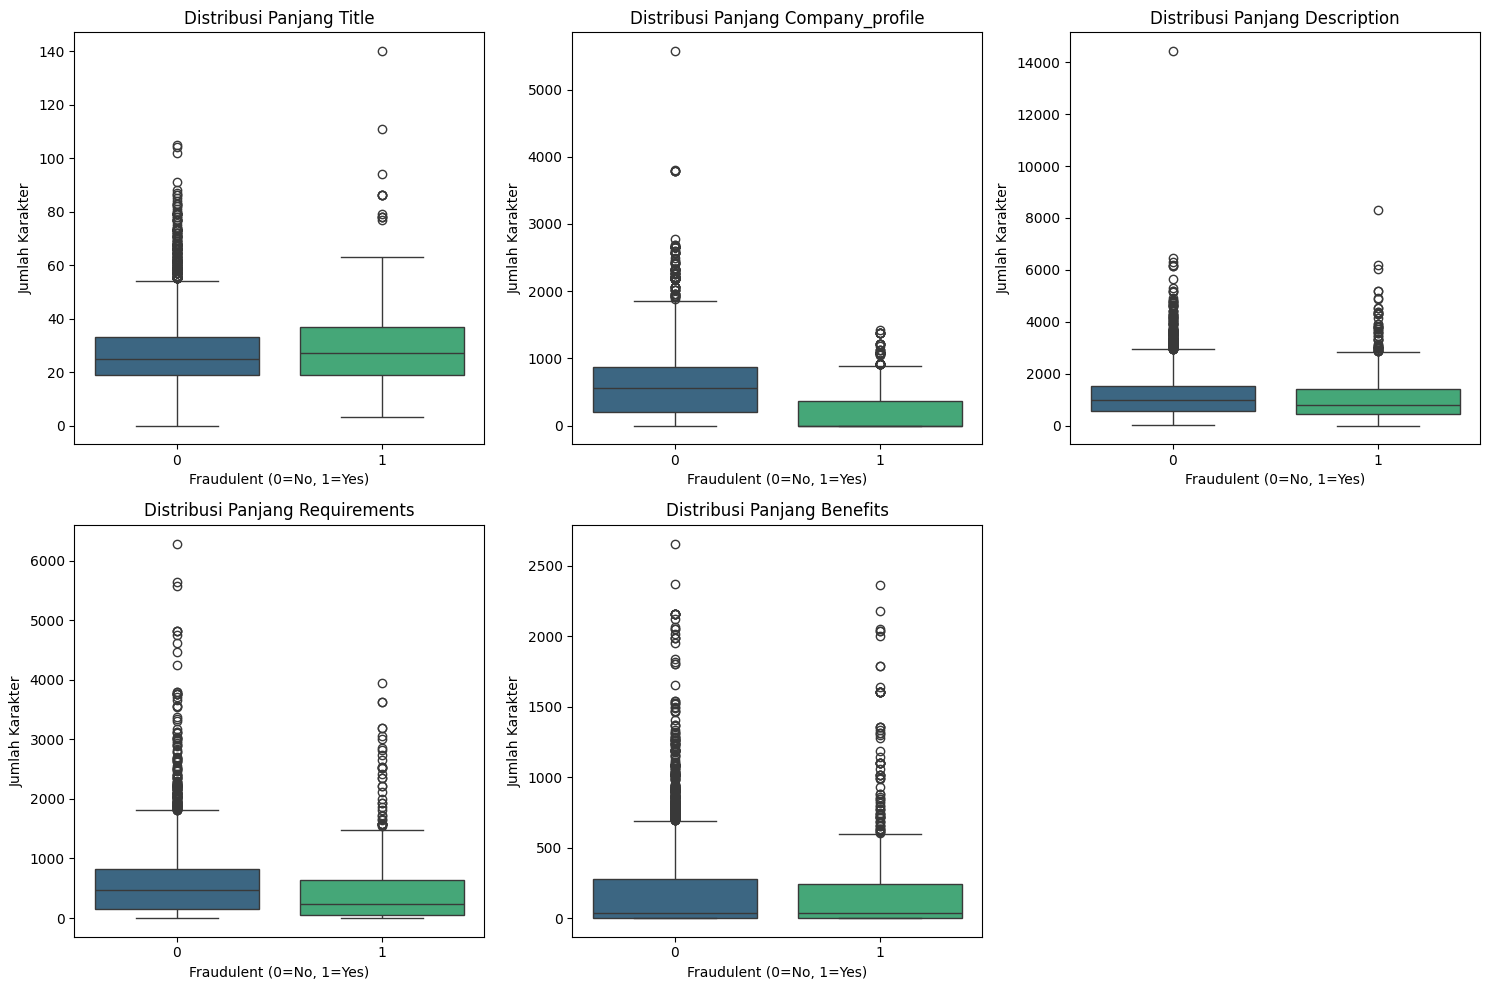


=== RATA-RATA PANJANG KARAKTER: REAL VS FRAUD ===
            title_len  company_profile_len  description_len  requirements_len  \
fraudulent                                                                      
0             27.7801             609.4397        1148.6693          586.9827   
1             29.8106             213.5727        1101.9688          432.1559   

            benefits_len  
fraudulent                
0               193.6580  
1               194.3868  


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Menyiapkan daftar kolom teks
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']

# 2. Menghitung panjang karakter untuk setiap kolom teks
for col in text_columns:
    df_balanced[col + "_len"] = df_balanced[col].astype(str).apply(len)

# 3. Analisis Statistik Deskriptif Berdasarkan Kategori Fraudulent (0 atau 1)
print("=== ANALISIS STATISTIK PANJANG TEKS PER KATEGORI ===")
for col in text_columns:
    col_name = col + "_len"
    print(f"\n--- Statistik Kolom: {col.upper()} ---")
    
    # Groupby berdasarkan label fraudulent untuk melihat perbedaan karakteristik
    summary = df_balanced.groupby('fraudulent')[col_name].describe()[['count', 'mean', 'std', '50%', 'max']]
    # Mengganti nama index agar lebih mudah dibaca
    summary.index = ['Real (0)', 'Fraud (1)']
    print(summary)

# 4. Visualisasi Distribusi menggunakan Boxplot
# Ini berguna untuk melihat rentang data dan outlier secara instan
plt.figure(figsize=(15, 10))
for i, col in enumerate(text_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='fraudulent', y=col + "_len", data=df_balanced, palette='viridis')
    plt.title(f'Distribusi Panjang {col.capitalize()}')
    plt.xlabel('Fraudulent (0=No, 1=Yes)')
    plt.ylabel('Jumlah Karakter')

plt.tight_layout()
plt.show()

# 5. Tambahan: Cek rata-rata secara keseluruhan dalam satu tabel ringkas
print("\n=== RATA-RATA PANJANG KARAKTER: REAL VS FRAUD ===")
len_cols = [c + "_len" for c in text_columns]
comparison_table = df_balanced.groupby('fraudulent')[len_cols].mean()
print(comparison_table)

In [ ]:
!pip install deep_translator

In [ ]:
import pandas as pd
from deep_translator import GoogleTranslator
from tqdm import tqdm

# 1. Inisialisasi Kolom
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']

# 2. Pre-processing & Filtering 5000+ Karakter
for col in text_columns:
    df_balanced[col] = df_balanced[col].fillna("").astype(str)

mask = (df_balanced[text_columns].applymap(len) < 5000).all(axis=1)
df_filtered = df_balanced[mask].copy()

df_test = df_filtered.head(10).copy()
print(f"Melakukan uji coba pada {len(df_test)} baris data pertama...")

# 3. Setup Translator
translator = GoogleTranslator(source='auto', target='id')

# 4. Fungsi Translate Row-by-Row
def translate_per_row(text):
    if not text or str(text).strip() == "" or str(text).lower() == "nan":
        return ""
    try:
        return translator.translate(text)
    except Exception as e:
        return text

# 5. Eksekusi Testing Per Kolom
tqdm.pandas()
for col in text_columns:
    new_col = col + "_id"
    print(f"\nUji coba kolom: {col}")
    df_test[new_col] = df_test[col].progress_apply(translate_per_row)

# 6. Cek Hasil Detail
print("\n" + "="*50)
print("HASIL PENGECEKAN MAPPING (10 BARIS)")
print("="*50)

# Kita tampilkan kolom asli bersandingan dengan hasil translate
for i, row in df_test.iterrows():
    print(f"\n[BARIS INDEX: {i}]")
    print(f"--- COMPANY PROFILE ---")
    print(f"Asli: {row['company_profile'][:50]}...")
    print(f"Indo: {row['company_profile_id'][:50]}...")
    
    print(f"--- DESCRIPTION ---")
    print(f"Asli: {row['description'][:50]}...")
    print(f"Indo: {row['description_id'][:50]}...")
    print("-" * 30)

# Cek apakah ada yang tertukar (Misal: Deskripsi masuk ke profil perusahaan)
print("\nSummary Check:")
print(df_test[['company_profile', 'company_profile_id', 'description', 'description_id']])

In [ ]:
# 1. Tampilkan 10 baris pertama hasil testing
print("=== PREVIEW HASIL TRANSLASI (10 BARIS) ===")

# Membuat list kolom berpasangan: [asli, hasil_id, asli, hasil_id, ...]
preview_cols = []
for col in text_columns:
    preview_cols.append(col)
    preview_cols.append(col + "_id")

# Menampilkan dataframe dengan styling agar teks tidak terpotong (opsional)
pd.set_option('display.max_colwidth', 100) # Biar teksnya kelihatan agak panjang
display(df_test[preview_cols])

# 2. Verifikasi Khusus: Cek baris yang Company Profile-nya Kosong
print("\n=== VERIFIKASI BARIS KOSONG (Kalo ada) ===")
# Ini untuk memastikan kalau aslinya kosong, ID-nya juga harus kosong
kosong_check = df_test[df_test['company_profile'] == ""][['company_profile', 'company_profile_id', 'description', 'description_id']]

if not kosong_check.empty:
    display(kosong_check)
else:
    print("Tidak ada Company Profile yang kosong di 10 baris pertama.")

# 3. Cek Statistik Panjang Karakter
print("\n=== PERBANDINGAN PANJANG KARAKTER ===")
for col in text_columns:
    print(f"{col.upper()}:")
    print(f"- Rata-rata Asli: {df_test[col].apply(len).mean():.2f}")
    print(f"- Rata-rata Indo: {df_test[col + '_id'].apply(len).mean():.2f}")

In [ ]:
import pandas as pd
from deep_translator import GoogleTranslator
from tqdm import tqdm

# 1. Inisialisasi Kolom
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']

# 2. Pre-processing & Filtering 5000+ Karakter
# Kita isi NaN dengan string kosong dulu agar pengecekan panjang tidak error
for col in text_columns:
    df_balanced[col] = df_balanced[col].fillna("").astype(str)

# Filter: Data dipertahankan jika length kolom teks < 5000 karakter
mask = (df_balanced[text_columns].applymap(len) < 5000).all(axis=1)
df_filtered = df_balanced[mask].copy()

print(f"Data awal: {len(df_balanced)}")
print(f"Data setelah filter (>5000 chars dropped): {len(df_filtered)}")

# 3. Setup Translator
translator = GoogleTranslator(source='auto', target='id')

# 4. Fungsi Translate
def translate_per_row(text):
    if not text or str(text).strip() == "" or str(text).lower() == "nan":
        return ""
    try:
        return translator.translate(text)
    except Exception as e:
        return text

# 5. Eksekusi Per Kolom (Mapping Pasti Aman)
tqdm.pandas()

for col in text_columns:
    new_col = col + "_id"
    print(f"\nProcessing column: {col} -> {new_col}")
    
    # Cara ini menjamin baris 1 tetap di baris 1, baris kosong tetap kosong
    df_filtered[new_col] = df_filtered[col].progress_apply(translate_per_row)

# 6. Final Verification
print("\n=== VERIFIKASI MAPPING ===")
# Kita cek baris awal untuk memastikan kolom asli vs kolom translate sudah sejajar
check_cols = ['company_profile', 'company_profile_id', 'description', 'description_id']
print(df_filtered[check_cols].head(10))

In [ ]:
df_filtered

In [ ]:
import pandas as pd

# 1. Atur agar Pandas menampilkan seluruh isi teks tanpa dipotong
pd.set_option('display.max_colwidth', None)  # Teks tidak akan dipotong sama sekali
pd.set_option('display.max_rows', 20)        # Menampilkan sampai 20 baris jika ada

# 2. Filter data yang rasionya di atas threshold
THRESHOLD = 0.3
df_still_english = df_filtered[df_filtered['eng_ratio'] > THRESHOLD].copy()

print(f"=== ANALISIS DATA MASIH DOMINAN ENGLISH (>{THRESHOLD}) ===")
print(f"Ditemukan: {len(df_still_english)} baris\n")

if not df_still_english.empty:
    # 3. Menampilkan kolom hasil gabungan dan rasionya
    # Kita hanya ambil kolom yang relevan supaya tidak pusing liatnya
    display(df_still_english[['translated_joined', 'eng_ratio']])
    
    # 4. Jika kamu ingin melihat per baris secara lebih 'manusiawi' (seperti dokumen)
    print("\n=== DETAIL TEKS PER BARIS (SAMPEL 3 TERATAS) ===")
    for i, row in df_still_english.head(3).iterrows():
        print(f"\n[INDEX: {i}] | Rasio English: {row['eng_ratio']:.4f}")
        print("-" * 50)
        print(row['translated_joined'])
        print("-" * 50)
else:
    print("Tidak ada data yang melebihi threshold.")

# Reset opsi display ke awal (optional, agar tidak mengganggu output sel lain)
pd.reset_option('display.max_colwidth')

In [ ]:
import re

def clean_noise(text):
    if not text or text == "":
        return ""
    
    # 1. Menangani simbol berulang (misal: ,,,, atau .... atau . . . .)
    # Menghapus simbol yang berulang lebih dari 2 kali menjadi satu simbol saja
    text = re.sub(r'([,.!?:;])\s*\1+', r'\1', text)
    
    # 2. Menghapus simbol yang "mengambang" (noise yang berdiri sendiri di antara spasi)
    # Contoh: "hosting . , . server" -> "hosting server"
    text = re.sub(r'\s+[,.!?:;]\s+', ' ', text)
    
    # 3. Menghapus karakter non-alfanumerik yang aneh tapi tetap mempertahankan tanda baca dasar
    # Kita pertahankan: huruf, angka, dan tanda baca standar (. , ! ? ( ) -)
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\(\)\-]', ' ', text)
    
    # 4. Merapikan spasi berlebih (Double space menjadi single space)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Daftar kolom yang ingin dicleaning (hasil translasi)
id_columns = ['title_id', 'company_profile_id', 'description_id', 'requirements_id', 'benefits_id']

print("Sedang melakukan cleaning noise pada kolom teks...")

# Terapkan fungsi cleaning ke setiap kolom
for col in id_columns:
    if col in df_filtered.columns:
        print(f"Cleaning: {col}")
        df_filtered[col] = df_filtered[col].astype(str).apply(clean_noise)

# Verifikasi hasil pada sampel yang tadi kamu berikan
sample_noise = "administrator sistem junior ... 2001, web hosting. 13, . , . , . , disesuaikan"
print("\nContoh Hasil Cleaning:")
print(f"Sebelum: {sample_noise}")
print(f"Sesudah: {clean_noise(sample_noise)}")

In [ ]:
import pandas as pd

# 1. Setting agar teks ditampilkan utuh (tidak dipotong ...)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 10)  # Bisa kamu sesuaikan jumlah barisnya

# 2. Pilih kolom hasil cleaning untuk dicek
id_columns = ['title_id', 'company_profile_id', 'description_id', 'requirements_id', 'benefits_id']

print("=== PREVIEW FULL TEXT SETELAH CLEANING NOISE ===")

# Menampilkan 10 baris pertama untuk verifikasi manual
# Kamu bisa ganti .head(10) jadi sampel acak .sample(5) untuk cek variasi noise
display(df_filtered[id_columns].head(10))

# 3. Verifikasi spesifik baris yang tadi kamu contohkan (jika ingin melihat per baris)
print("\n=== DETAIL PENGECEKAN PER BARIS (Contoh 3 Baris Teratas) ===")
for i, row in df_filtered[id_columns].head(3).iterrows():
    print(f"\n[INDEX: {i}]")
    print(f"TITLE       : {row['title_id']}")
    print(f"DESC        : {row['description_id'][:500]}...") # Deskripsi panjang kita tampilkan 500 karakter awal
    print(f"CO_PROFILE  : {row['company_profile_id']}")
    print("-" * 80)

# Reset opsi display ke default (optional)
# pd.reset_option('display.max_colwidth')

In [ ]:
import pandas as pd

# 1. Menghitung ulang panjang karakter untuk kolom hasil translasi (jika belum)
id_columns = ['title_id', 'company_profile_id', 'description_id', 'requirements_id', 'benefits_id']
len_cols = []

for col in id_columns:
    col_len_name = col + "_len"
    df_filtered[col_len_name] = df_filtered[col].astype(str).apply(len)
    len_cols.append(col_len_name)

# 2. Menampilkan Statistik Deskriptif: Fraud (1) vs Non-Fraud (0)
print("=== STATISTIK PANJANG KARAKTER PER KATEGORI (SETELAH CLEANING) ===")

for col in len_cols:
    print(f"\n--- Analisis Kolom: {col.upper()} ---")
    # Groupby berdasarkan label fraudulent
    stats_grouped = df_filtered.groupby('fraudulent')[col].describe()[['count', 'mean', 'std', '50%', 'max']]
    stats_grouped.index = ['Real (0)', 'Fraud (1)']
    print(stats_grouped)

# 3. Ringkasan Perbandingan Rata-rata (Mean Comparison)
print("\n=== PERBANDINGAN RATA-RATA PANJANG: REAL VS FRAUD ===")
comparison_summary = df_filtered.groupby('fraudulent')[len_cols].mean().transpose()
comparison_summary.columns = ['Mean Real (0)', 'Mean Fraud (1)']
print(comparison_summary)

# 4. Distribusi Label
print("\n=== DISTRIBUSI LABEL ===")
print(df_filtered['fraudulent'].value_counts())

# 5. Simpan ke CSV
file_name = "dataset_translated_hierarchy.csv"
df_filtered.to_csv(file_name, index=False)
print(f"\nBerhasil disimpan ke: {file_name}")

# EKSTRAKSI FITUR KONTEKSTUAL UNTUK FEATURE FUSION

In [13]:
import pandas as pd

PATH = "/kaggle/input/datasets/bintangryan/translated-hierarchy/dataset_translated_hierarchy.csv"
df_filtered = pd.read_csv(PATH)

# =====================================================================
# 1. CETAK INFORMASI METADATA & DISTRIBUSI LABEL 
# =====================================================================
print("=" * 60)
print(" INFO DATASET")
print("=" * 60)
print(f"Shape Dataset    : {df_filtered.shape[0]:,} baris | {df_filtered.shape[1]} kolom")
print(f"Daftar Kolom     : {df_filtered.columns.tolist()}")

print("\n" + "=" * 60)
print(" DISTRIBUSI KELAS TARGET (FRAUDULENT)")
print("=" * 60)
vc = df_filtered['fraudulent'].value_counts()
total_data = len(df_filtered)
print(f"Total Data       : {total_data:,}")
print(f"Fraud (1)        : {vc.get(1, 0):,} ({vc.get(1, 0)/total_data*100:.2f}%)")
print(f"Legit/Non-Fraud (0): {vc.get(0, 0):,} ({vc.get(0, 0)/total_data*100:.2f}%)")

# =====================================================================
# 2. TAMPILKAN SAMPEL DATA (TRUNCATED / TIDAK FULL TEXT)
# =====================================================================
print("\n" + "=" * 60)
print(" SAMPLE DATA (5 BARIS PERTAMA)")
print("=" * 60)

# option_context memastikan max_colwidth=60 hanya berlaku di baris ini saja,
# sehingga tidak merusak konfigurasi global notebook kamu.
with pd.option_context('display.max_colwidth', 60):
    display(df_filtered.head(5))

 INFO DATASET
Shape Dataset    : 4,244 baris | 36 kolom
Daftar Kolom     : ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent', 'all_text_cleaned', 'title_len', 'company_profile_len', 'description_len', 'requirements_len', 'benefits_len', 'title_id', 'company_profile_id', 'description_id', 'requirements_id', 'benefits_id', 'translated_joined', 'eng_ratio', 'title_id_len', 'company_profile_id_len', 'description_id_len', 'requirements_id_len', 'benefits_id_len']

 DISTRIBUSI KELAS TARGET (FRAUDULENT)
Total Data       : 4,244
Fraud (1)        : 706 (16.64%)
Legit/Non-Fraud (0): 3,538 (83.36%)

 SAMPLE DATA (5 BARIS PERTAMA)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,all_text_cleaned,title_len,company_profile_len,description_len,requirements_len,benefits_len,title_id,company_profile_id,description_id,requirements_id,benefits_id,translated_joined,eng_ratio,title_id_len,company_profile_id_len,description_id_len,requirements_id_len,benefits_id_len
0,4429,"video journalist, dari and pashto language","US, DC, Washington",NaN,NaN,applied memetics llc is a professional services company ...,the video journalist shall have at least five years of c...,the video journalist shall properly complete all daily t...,NaN,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Broadcast Media,NaN,0,"video journalist, dari and pashto language. applied meme...",42,1238,978,478,0,"jurnalis video, bahasa dari dan pashto",memetics terapan llc adalah perusahaan layanan profesion...,jurnalis video harus memiliki setidaknya lima tahun peng...,jurnalis video harus menyelesaikan semua tugas sehari-ha...,NaN,"jurnalis video, bahasa dari dan pashto memetics terapan ...",0.2010,38,1404,978,529,0
1,15017,senior recruiter,"DE, BE, Berlin",Operations,NaN,babbel enables anyone to learn languages in an easy and ...,we are looking for a full time senior recruiter to start...,"5 years work experience in in business administration, l...",the potential to change the way of learning for millions...,0,1,1,Full-time,Mid-Senior level,Master's Degree,E-Learning,Human Resources,0,senior recruiter. babbel enables anyone to learn languag...,16,653,956,491,641,perekrut senior,babbel memungkinkan siapa saja belajar bahasa dengan car...,kami mencari perekrut senior penuh waktu untuk segera me...,"5 tahun pengalaman kerja di bidang administrasi bisnis, ...",potensi untuk mengubah cara belajar bagi jutaan pengguna...,perekrut senior babbel memungkinkan siapa saja belajar b...,0.1919,15,705,994,561,693
2,7483,licensed practical nurse,"US, KY,",NaN,NaN,NaN,apply using below link thomson hood veterans center is a...,NaN,NaN,0,0,0,Full-time,NaN,NaN,Hospital & Health Care,NaN,1,licensed practical nurse. apply using below link thomson...,24,0,624,0,0,perawat praktis berlisensi,NaN,mendaftar menggunakan tautan di bawah ini pusat veteran ...,NaN,NaN,perawat praktis berlisensi mendaftar menggunakan tautan...,0.2041,26,0,690,0,0
3,10137,regional account executive,"US, TX, Houston",NaN,NaN,prosulting is people the pro sulting difference is easy ...,are you ready for a career change and an opportunity to ...,minimum 3 years experience in enterprise software sales ...,comprehensive benefits.,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Legal Services,Business Development,0,regional account executive. prosulting is people the pro...,26,1442,1423,678,23,eksekutif akun regional,"prosulting adalah orang-orang, perbedaan pro sulting mud...",apakah Anda siap untuk perubahan karier dan peluang untu...,minimal 3 tahun pengalaman dalam penjualan perangkat lun...,manfaat yang komprehensif.,"eksekutif akun regional prosulting adalah orang-orang, p...",0.2008,23,1654,1543,733,26
4,7919,ui ux front end developer,"GR, I, Kifissia",UI Production,NaN,NaN,"the ideal candidate will be strong with html5, css3 and ...",NaN,what's in it for you competitive salary equity options p...,0,0,0,Full-time,Associate,Bachelor's Degree,Information Technology and Services,Production,0,ui ux front end developer. the ideal candidate will be s...,25,0,530,0,245,pengembang ujung depan ui ux,NaN,"kandidat yang ideal akan kuat dengan html5, css3 dan jav...",NaN,"apa untungnya bagi Anda, gaji yang kompetitif, opsi ekui...",pengembang ujung depan ui ux kandidat yang ideal akan k...,0.2097,28,0,577,0,278


In [14]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Inisialisasi basis data
df_cleaned = df_filtered[["job_id", "fraudulent"]].copy()
target_text_cols = [
    "company_profile_id", "description_id", "requirements_id", "benefits_id"
]

# 1. Fitur Panjang Teks (Length Features) - Dihitung Ulang Langsung
for col in target_text_cols:
    df_cleaned[f"{col}_len"] = df_filtered[col].fillna("").astype(str).str.len()

len_cols = [f"{col}_len" for col in target_text_cols]
df_cleaned["text_indo_len"] = df_cleaned[len_cols].sum(axis=1)

# 2. Fitur Keberadaan Teks (Presence Features)
for col in target_text_cols:
    df_cleaned[f"has_{col}"] = (df_cleaned[f"{col}_len"] > 5).astype(int)

has_cols = [f"has_{col}" for col in target_text_cols]
df_cleaned["has_fulltext"] = df_cleaned[has_cols].all(axis=1).astype(int)
df_cleaned["has_profile_and_desc"] = (
    (df_cleaned["has_company_profile_id"] == 1) & 
    (df_cleaned["has_description_id"] == 1)
).astype(int)

# 3. Fitur Akumulasi Nilai Hilang (Missing Values)
missing_cols = [
    "title", "location", "department", "salary_range", "company_profile", 
    "description", "requirements", "benefits", "telecommuting", "has_company_logo", 
    "has_questions", "employment_type", "required_experience", "required_education", 
    "industry", "function"
]
available_cols = [c for c in missing_cols if c in df_filtered.columns]
df_cleaned["missing_info_count"] = df_filtered[available_cols].isnull().sum(axis=1)

# 4. Ekstraksi Fitur Metadata Biner (Binary Flags)
meta_cols = ["salary_range", "required_education", "required_experience", "employment_type"]
for col in meta_cols:
    df_cleaned[f"has_{col}"] = df_filtered[col].notna().astype(int)
df_cleaned["has_questions"] = df_filtered["has_questions"].fillna(0).astype(int)

# 5. Transformasi Fitur Kategorikal (Label Encoding)
label_encoder = LabelEncoder()
for col in ["required_education", "required_experience"]:
    if col in df_filtered.columns:
        df_cleaned[col] = label_encoder.fit_transform(
            df_filtered[col].fillna("Unknown").astype(str)
        )
df_cleaned["has_company_logo"] = df_filtered["has_company_logo"].fillna(0).astype(int)

# 6. Konsolidasi Array Fitur Akhir
ALL_FEATURES = (
    [f"{col}_len" for col in target_text_cols]
    + ["text_indo_len"]
    + [f"has_{col}" for col in target_text_cols]
    + ["has_fulltext", "has_profile_and_desc", "missing_info_count"]
    + [f"has_{c}" for c in meta_cols]
    + ["has_questions", "has_company_logo", "required_education", "required_experience"]
)

# Menampilkan Output Ringkasan Statistik
print(f"Feature Engineering Selesai! Dimensi Data: {df_cleaned.shape}")
display(df_cleaned.groupby("fraudulent")[ALL_FEATURES].mean().T)

Feature Engineering Selesai! Dimensi Data: (4244, 22)


fraudulent,0,1
company_profile_id_len,705.3185,252.2975
description_id_len,1300.3335,1243.4051
requirements_id_len,670.7507,510.8754
benefits_id_len,232.9144,223.9618
text_indo_len,2909.3171,2230.5397
has_company_profile_id,0.8267,0.3428
has_description_id,0.9997,0.9972
has_requirements_id,0.8533,0.8201
has_benefits_id,0.5859,0.5453
has_fulltext,0.4813,0.2507


Visualisasi distribusi fitur non-text: Fraud vs Non-Fraud



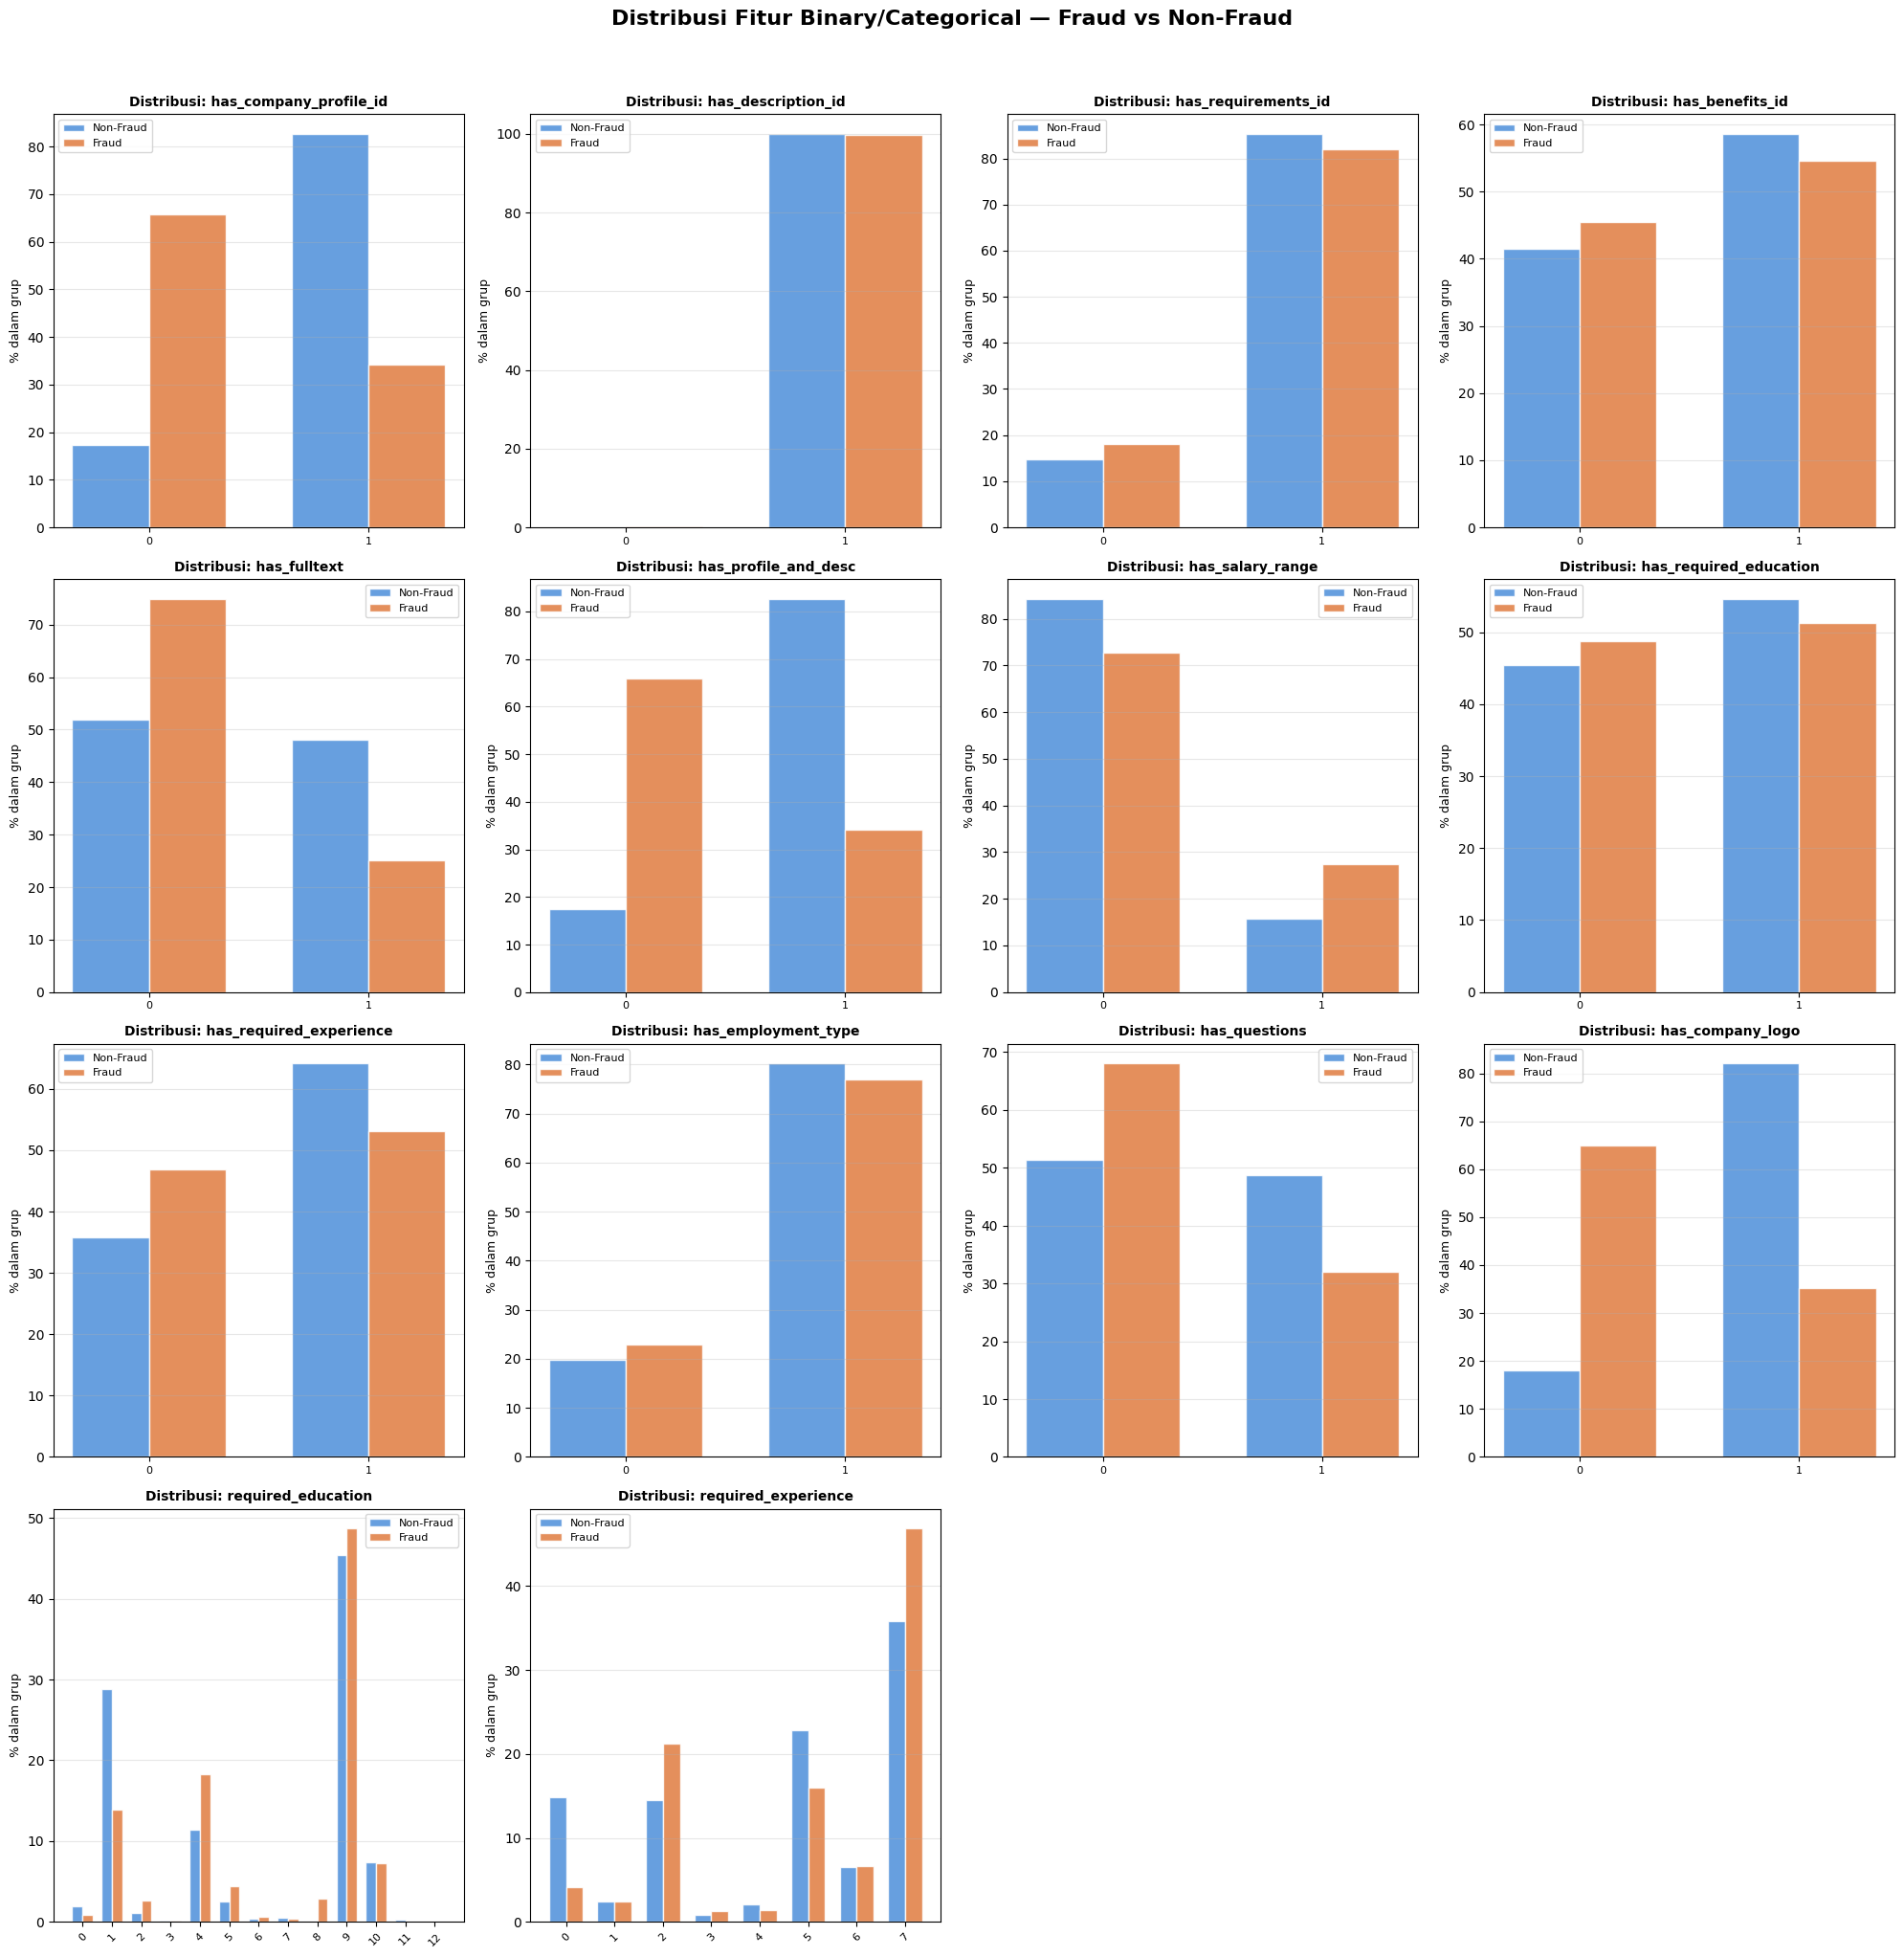

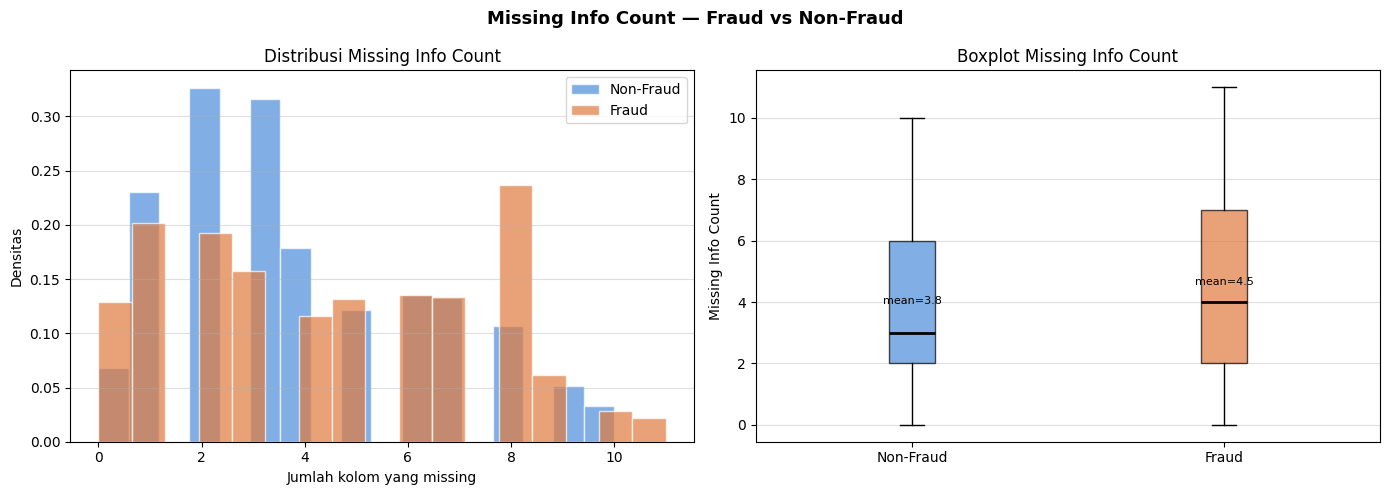

✅ Plot missing info count tersimpan


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Visualisasi distribusi fitur non-text: Fraud vs Non-Fraud\n")

# Memisahkan data berdasarkan target
fraud = df_cleaned[df_cleaned["fraudulent"] == 1]
non_fraud = df_cleaned[df_cleaned["fraudulent"] == 0]

target_text_cols = [
    "company_profile_id", "description_id", "requirements_id", "benefits_id"
]
meta_cols = [
    "salary_range", "required_education", "required_experience", "employment_type"
]

has_text_features = [f"has_{col}" for col in target_text_cols] + [
    "has_fulltext", "has_profile_and_desc"
]
categorical_presence = [f"has_{col}" for col in meta_cols] + ["has_questions"]
base_features = ["has_company_logo", "required_education", "required_experience"]

# Menggabungkan seluruh fitur kategorikal/biner untuk divisualisasikan
binary_cat_features = has_text_features + categorical_presence + base_features

# Hitung dimensi grid subplot secara dinamis
n_features = len(binary_cat_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

# Setup canvas matplotlib
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
fig.suptitle(
    "Distribusi Fitur Binary/Categorical — Fraud vs Non-Fraud",
    fontsize=16, fontweight="bold", y=1.02
)
axes = axes.flatten()

colors = {"Non-Fraud": "#4C8EDA", "Fraud": "#E07B3F"}

# Loop untuk menggambar bar plot tiap fitur
for i, feat in enumerate(binary_cat_features):
    ax = axes[i]
    unique_vals = sorted(df_cleaned[feat].unique())
    
    non_fraud_counts = non_fraud[feat].value_counts(normalize=True)
    fraud_counts = fraud[feat].value_counts(normalize=True)
    
    non_fraud_pct = [non_fraud_counts.get(v, 0) * 100 for v in unique_vals]
    fraud_pct = [fraud_counts.get(v, 0) * 100 for v in unique_vals]

    x = np.arange(len(unique_vals))
    width = 0.35
    
    ax.bar(
        x - width/2, non_fraud_pct, width, label="Non-Fraud",
        color=colors["Non-Fraud"], alpha=0.85, edgecolor="white"
    )
    ax.bar(
        x + width/2, fraud_pct, width, label="Fraud",
        color=colors["Fraud"], alpha=0.85, edgecolor="white"
    )

    ax.set_title(f"Distribusi: {feat}", fontsize=10, fontweight="bold")
    ax.set_ylabel("% dalam grup", fontsize=9)
    ax.set_xticks(x)
    
    # Kondisi rotasi label sumbu X agar rapi jika teksnya panjang
    ax.set_xticklabels(
        [str(v) for v in unique_vals], 
        fontsize=8, 
        rotation=45 if len(unique_vals) > 3 else 0
    )
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

for j in range(len(binary_cat_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Missing Info Count — Fraud vs Non-Fraud", fontsize=13, fontweight="bold")
 
# Subplot 1: Histogram / Density Plot
ax = axes[0]
ax.hist(
    non_fraud["missing_info_count"], bins=17, alpha=0.7, color=colors["Non-Fraud"],
    label="Non-Fraud", density=True, edgecolor="white"
)
ax.hist(
    fraud["missing_info_count"], bins=17, alpha=0.7, color=colors["Fraud"],
    label="Fraud", density=True, edgecolor="white"
)
ax.set_xlabel("Jumlah kolom yang missing")
ax.set_ylabel("Densitas")
ax.set_title("Distribusi Missing Info Count")
ax.legend()
ax.grid(axis="y", alpha=0.4)
 
# Subplot 2: Boxplot
ax2 = axes[1]
data_box = [non_fraud["missing_info_count"].values, fraud["missing_info_count"].values]
bp = ax2.boxplot(
    data_box, patch_artist=True, labels=["Non-Fraud", "Fraud"],
    medianprops=dict(color="black", linewidth=2)
)

bp["boxes"][0].set_facecolor(colors["Non-Fraud"])
bp["boxes"][0].set_alpha(0.7)
bp["boxes"][1].set_facecolor(colors["Fraud"])
bp["boxes"][1].set_alpha(0.7)
ax2.set_ylabel("Missing Info Count")
ax2.set_title("Boxplot Missing Info Count")
ax2.grid(axis="y", alpha=0.4)
 
# Menambahkan anotasi nilai rata-rata (mean) pada boxplot
for idx, (grp, lbl) in enumerate([(non_fraud, "Non-Fraud"), (fraud, "Fraud")], 1):
    m = grp["missing_info_count"].mean()
    ax2.text(idx, m + 0.1, f"mean={m:.1f}", ha="center", fontsize=8, color="black")
 
plt.tight_layout()
plt.savefig("missing_info_count_dist.png", dpi=130, bbox_inches="tight")
plt.show()

print("✅ Plot missing info count tersimpan")

Menghitung Feature Importance...



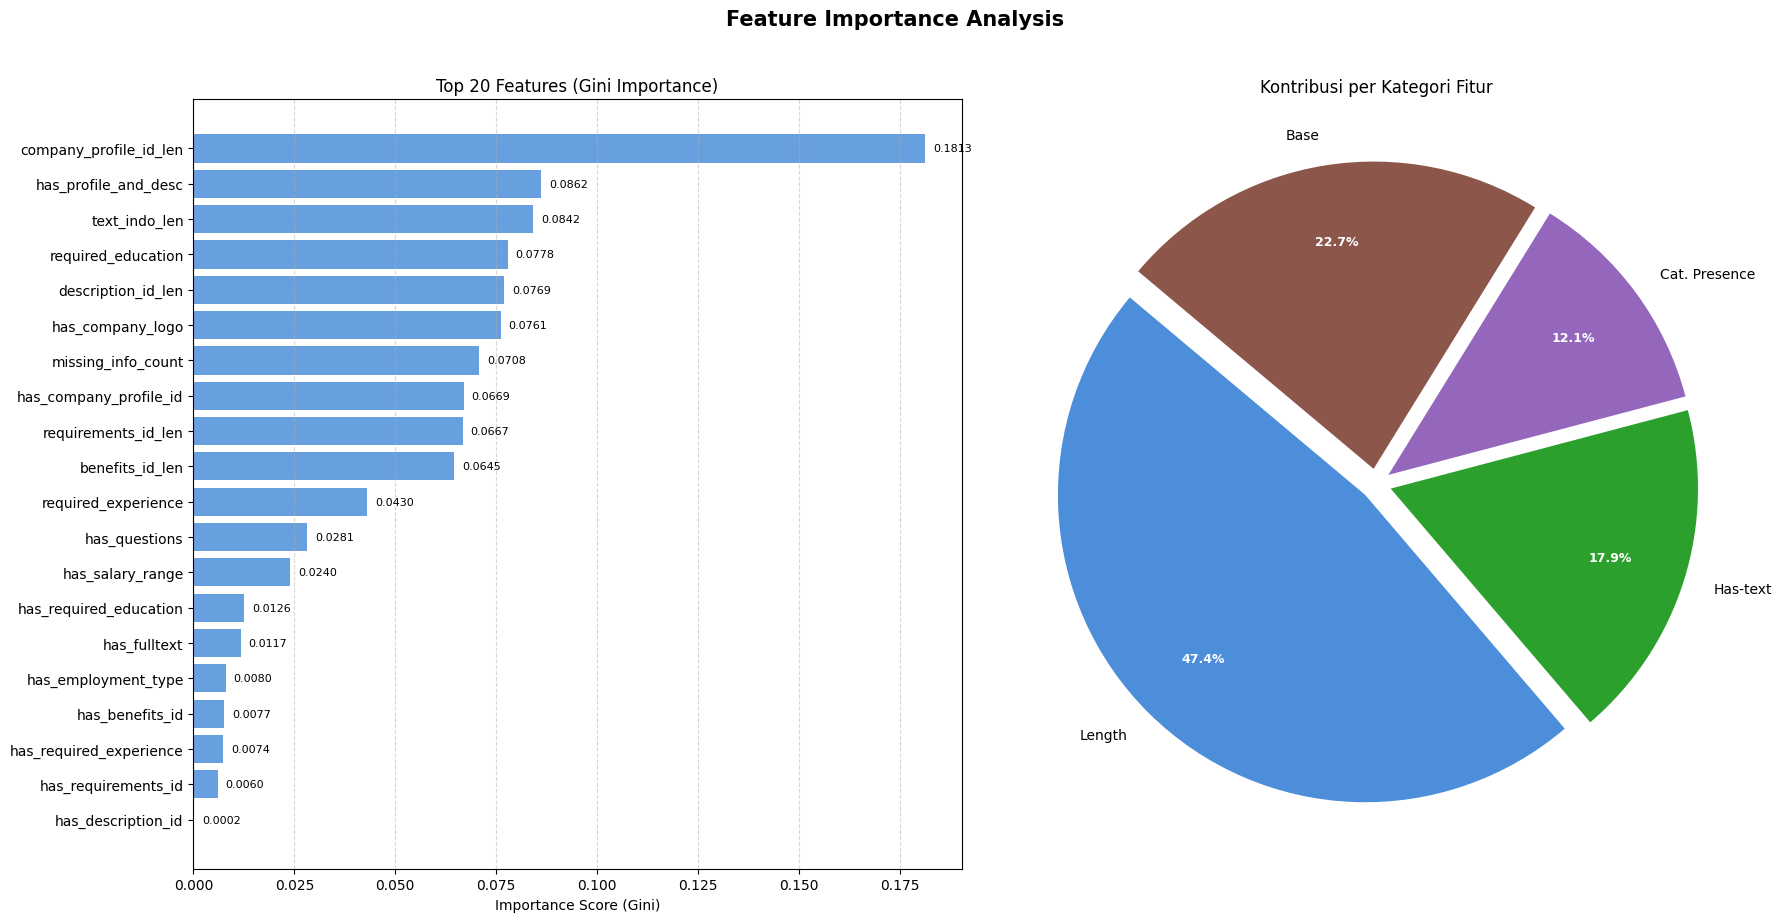


Menghitung Permutation Importance ...


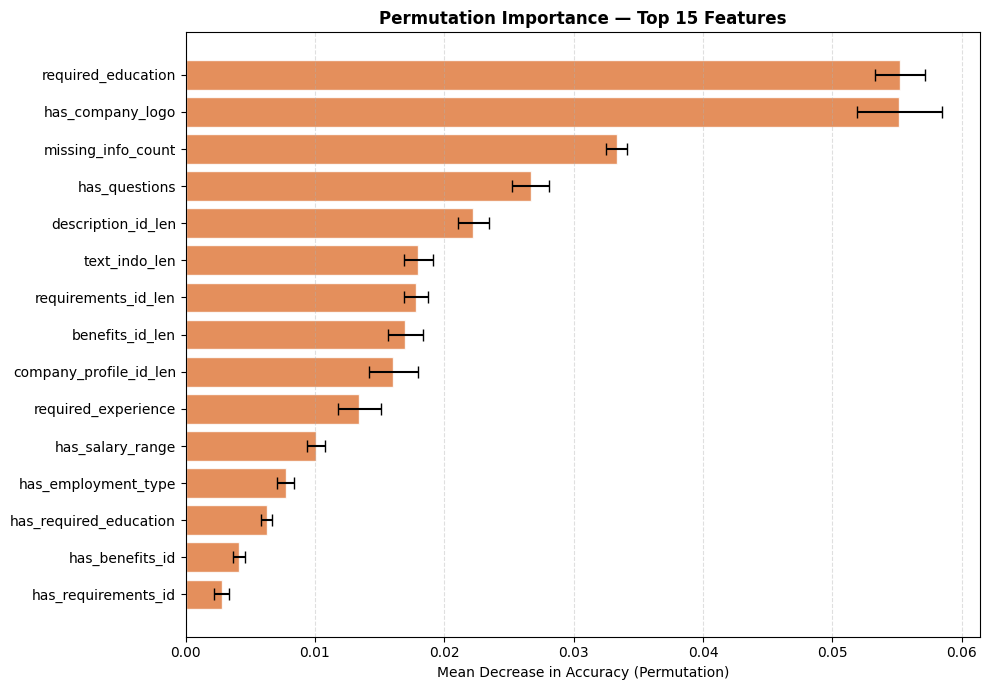

✅ Feature Importance selesai!


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

print("Menghitung Feature Importance...\n")

X = df_cleaned[ALL_FEATURES].fillna(0)
y = df_cleaned['fraudulent']

# Kelompok fitur untuk visualisasi kategori
len_features = [
    "company_profile_id_len",
    "description_id_len",
    "requirements_id_len",
    "benefits_id_len",
    "text_indo_len",
]

has_text_features = [
    "has_company_profile_id",
    "has_description_id",
    "has_requirements_id",
    "has_benefits_id",
    "has_fulltext",
    "has_profile_and_desc",
]

categorical_presence = [
    "required_education",
    "required_experience",
]

base_features = [
    "missing_info_count",
    "has_salary_range",
    "has_required_education",
    "has_required_experience",
    "has_employment_type",
    "has_questions",
    "has_company_logo",
]

misc_features = list(
    set(ALL_FEATURES)
    - set(len_features)
    - set(has_text_features)
    - set(categorical_presence)
    - set(base_features)
)

# ---- 5a. Random Forest Importance  ----
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',  
    random_state=42,
    n_jobs=-1,
)
rf.fit(X, y)

fi_df = (
    pd.DataFrame({'feature': ALL_FEATURES, 'importance': rf.feature_importances_})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.suptitle(
    "Feature Importance Analysis", fontsize=15, fontweight='bold', y=1.02
)

# Top 20 Bar Chart
top20 = fi_df.head(20)
ax = axes[0]
bars = ax.barh(
    top20['feature'][::-1], top20['importance'][::-1], color='#4C8EDA', alpha=0.85
)
ax.set_xlabel('Importance Score (Gini)')
ax.set_title('Top 20 Features (Gini Importance)', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Tambahkan label angka di ujung bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.4f}',
        va='center',
        fontsize=8,
    )

# Per kategori Pie Chart 
cat_imp = {
    'Length': fi_df[fi_df['feature'].isin(len_features)]['importance'].sum(),
    'Has-text': fi_df[fi_df['feature'].isin(has_text_features)][
        'importance'
    ].sum(),
    'Cat. Presence': fi_df[fi_df['feature'].isin(categorical_presence)][
        'importance'
    ].sum(),
    'Base': fi_df[fi_df['feature'].isin(base_features)]['importance'].sum(),
    'Misc': fi_df[fi_df['feature'].isin(misc_features)]['importance'].sum(),
}

ax2 = axes[1]
cat_colors = ['#4C8EDA', '#2CA02C', '#9467BD', '#8C564B', '#AAAAAA']

# Filter kategori yang nol agar pie chart tetap bersih
cat_labels = [k for k, v in cat_imp.items() if v > 0]
cat_values = [v for v in cat_imp.values() if v > 0]

wedges, texts, autotexts = ax2.pie(
    cat_values,
    labels=cat_labels,
    autopct='%1.1f%%',
    colors=cat_colors[: len(cat_labels)],
    startangle=140,
    pctdistance=0.75,
    explode=[0.05] * len(cat_labels),  
)
plt.setp(autotexts, size=9, weight="bold", color="white")
ax2.set_title('Kontribusi per Kategori Fitur', fontsize=12)

plt.tight_layout()
plt.show()

# ---- 5b. Permutation Importance  ----
print(
    "\nMenghitung Permutation Importance ..."
)

# Gunakan X dan y yang sama dengan saat fit
perm = permutation_importance(rf, X, y, n_repeats=5, random_state=42, n_jobs=-1)

perm_df = (
    pd.DataFrame(
        {
            'feature': ALL_FEATURES,
            'mean_imp': perm.importances_mean,
            'std_imp': perm.importances_std,
        }
    )
    .sort_values('mean_imp', ascending=False)
    .head(15)
)  # Ambil top 15 setelah dihitung

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    perm_df['feature'][::-1],
    perm_df['mean_imp'][::-1],
    xerr=perm_df['std_imp'][::-1],
    color='#E07B3F',
    alpha=0.85,
    capsize=4,
    edgecolor='white',
)
ax.set_xlabel('Mean Decrease in Accuracy (Permutation)')
ax.set_title(
    'Permutation Importance — Top 15 Features', fontsize=12, fontweight='bold'
)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("✅ Feature Importance selesai!")

Chi-Square Test — Fitur Kategorikal vs Fraudulent

                Feature     Chi2  p-value  DoF  Cramér's V Signifikan
   has_profile_and_desc 727.9062   0.0000    1      0.4141       ✅ Ya
 has_company_profile_id 725.3886   0.0000    1      0.4134       ✅ Ya
       has_company_logo 674.0803   0.0000    1      0.3985       ✅ Ya
     required_education 185.9281   0.0000   12      0.2093       ✅ Ya
     missing_info_count 183.4068   0.0000   11      0.2079       ✅ Ya
           has_fulltext 125.9464   0.0000    1      0.1723       ✅ Ya
    required_experience 102.9675   0.0000    7      0.1558       ✅ Ya
          has_questions  65.1177   0.0000    1      0.1239       ✅ Ya
       has_salary_range  54.2227   0.0000    1      0.1130       ✅ Ya
has_required_experience  29.9427   0.0000    1      0.0840       ✅ Ya
    has_requirements_id   4.7713   0.0289    1      0.0335       ✅ Ya
        has_benefits_id   3.8153   0.0508    1      0.0300    ❌ Tidak
    has_employment_type   3.4406   0.06

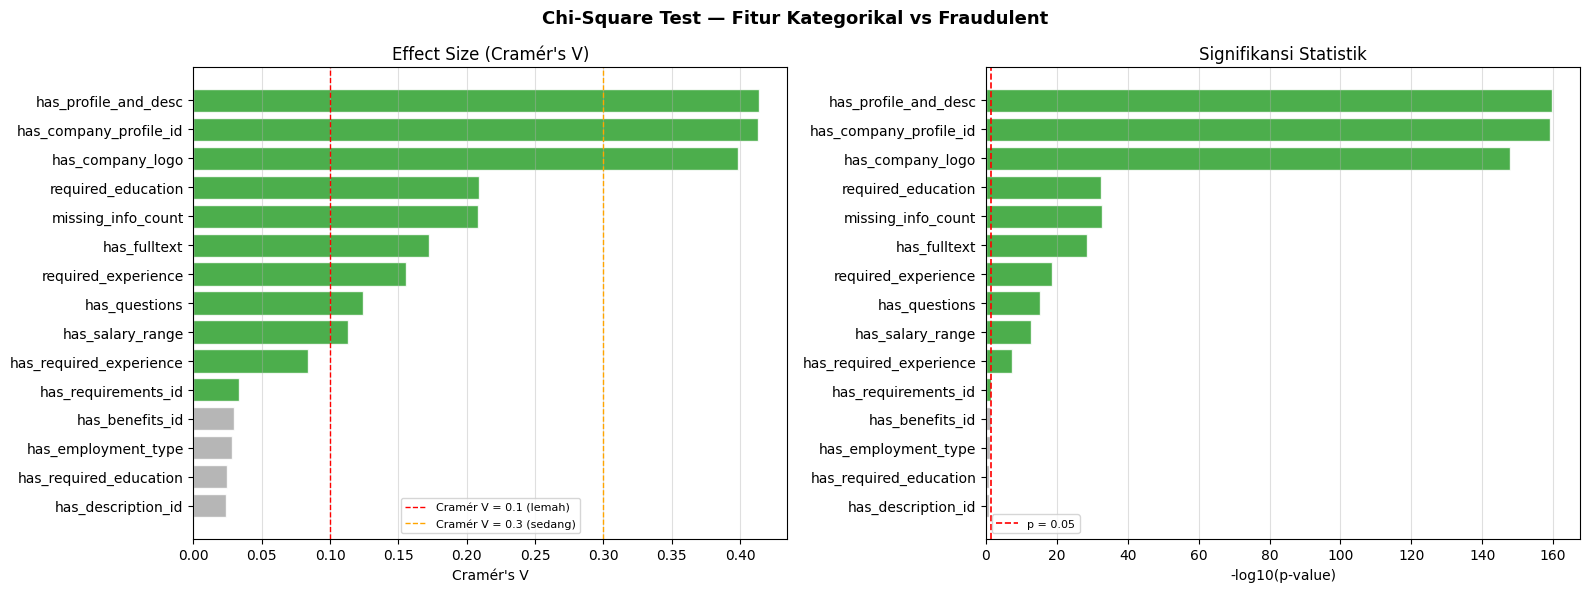


✅ Signifikan (p<0.05): 11 fitur | Tidak signifikan: 4 fitur


In [19]:
print("Chi-Square Test — Fitur Kategorikal vs Fraudulent\n")
 
chi2_features = has_text_features + categorical_presence + base_features
 
results = []
for feat in chi2_features:
    contingency = pd.crosstab(df_cleaned[feat], df_cleaned['fraudulent'])
    if contingency.shape == (2, 2) or contingency.shape[1] == 2:
        chi2, p, dof, expected = chi2_contingency(contingency)
        n         = contingency.values.sum()
        cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
        results.append({
            'Feature'   : feat,
            'Chi2'      : round(chi2, 4),
            'p-value'   : p,
            'DoF'       : dof,
            "Cramér's V": round(cramers_v, 4),
            'Signifikan': '✅ Ya' if p < 0.05 else '❌ Tidak'
        })
 
chi2_df = pd.DataFrame(results).sort_values("Cramér's V", ascending=False)
print(chi2_df.to_string(index=False))
 
# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Chi-Square Test — Fitur Kategorikal vs Fraudulent",
             fontsize=13, fontweight='bold')
 
sig   = chi2_df[chi2_df['p-value'] < 0.05]
insig = chi2_df[chi2_df['p-value'] >= 0.05]
 
ax = axes[0]
bar_colors = ['#2CA02C' if p < 0.05 else '#AAAAAA' for p in chi2_df['p-value']]
ax.barh(chi2_df['Feature'][::-1], chi2_df["Cramér's V"][::-1],
        color=bar_colors[::-1], alpha=0.85, edgecolor='white')
ax.axvline(0.1, color='red', linestyle='--', linewidth=1, label='Cramér V = 0.1 (lemah)')
ax.axvline(0.3, color='orange', linestyle='--', linewidth=1, label='Cramér V = 0.3 (sedang)')
ax.set_xlabel("Cramér's V")
ax.set_title("Effect Size (Cramér's V)")
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.4)
 
ax2 = axes[1]
neg_log_p = -np.log10(chi2_df['p-value'].clip(lower=1e-300))
bar_colors2 = ['#2CA02C' if p < 0.05 else '#AAAAAA' for p in chi2_df['p-value']]
ax2.barh(chi2_df['Feature'][::-1], neg_log_p[::-1],
         color=bar_colors2[::-1], alpha=0.85, edgecolor='white')
ax2.axvline(-np.log10(0.05), color='red', linestyle='--',
            linewidth=1.2, label='p = 0.05')
ax2.set_xlabel('-log10(p-value)')
ax2.set_title('Signifikansi Statistik')
ax2.legend(fontsize=8)
ax2.grid(axis='x', alpha=0.4)
 
plt.tight_layout()
plt.savefig('chi2_test_results.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"\n✅ Signifikan (p<0.05): {len(sig)} fitur | Tidak signifikan: {len(insig)} fitur")

In [20]:
import pandas as pd

# 1. Menentukan daftar kolom panjang karakter
# Mengambil kolom yang berakhiran _len dari df_cleaned atau df_selected sebelum scaling
len_cols = [col for col in df_cleaned.columns if col.endswith('_len')]

print("="*80)
print(f"{'STATISTIK DESKRIPTIF PANJANG KARAKTER (RAW)':^80}")
print("="*80)

for col in len_cols:
    print(f"\nANALISIS KOLOM: {col.upper()}")
    
    # Menghitung statistik deskriptif dipisahkan berdasarkan label
    stats = df_cleaned.groupby('fraudulent')[col].describe()[['count', 'mean', 'std', 'min', '50%', 'max']]
    
    # Mengganti index agar lebih jelas
    stats.index = ['Real (0)', 'Fraud (1)']
    
    # Menampilkan tabel statistik
    display(stats)
    
    # Hitung perbedaan rata-rata dalam persen
    mean_real = stats.loc['Real (0)', 'mean']
    mean_fraud = stats.loc['Fraud (1)', 'mean']
    diff_pct = ((mean_fraud - mean_real) / mean_real) * 100
    
    print(f"Info: Rata-rata panjang teks Fraud {'lebih panjang' if diff_pct > 0 else 'lebih pendek'} {abs(diff_pct):.2f}% dibandingkan Real.")
    print("-" * 40)

# 2. Ringkasan Perbandingan Median (Lebih tahan terhadap outlier)
print("\n" + "="*80)
print(f"{'PERBANDINGAN MEDIAN (50%) SEMUA KOLOM':^80}")
print("="*80)
median_comp = df_cleaned.groupby('fraudulent')[len_cols].median().transpose()
median_comp.columns = ['Median Real (0)', 'Median Fraud (1)']
display(median_comp)

                  STATISTIK DESKRIPTIF PANJANG KARAKTER (RAW)                   

ANALISIS KOLOM: COMPANY_PROFILE_ID_LEN


,count,mean,std,min,50%,max
Real (0),3538.0000,705.3185,605.3505,0.0000,658.0000,4182.0000
Fraud (1),706.0000,252.2975,407.1332,0.0000,0.0000,1613.0000


Info: Rata-rata panjang teks Fraud lebih pendek 64.23% dibandingkan Real.
----------------------------------------

ANALISIS KOLOM: DESCRIPTION_ID_LEN


,count,mean,std,min,50%,max
Real (0),3538.0000,1300.3335,864.9602,5.0000,1120.5000,5364.0000
Fraud (1),706.0000,1243.4051,1005.6825,0.0000,902.0000,5379.0000


Info: Rata-rata panjang teks Fraud lebih pendek 4.38% dibandingkan Real.
----------------------------------------

ANALISIS KOLOM: REQUIREMENTS_ID_LEN


...

,count,mean,std,min,50%,max
Real (0),3538.0000,232.9144,361.0261,0.0000,68.0000,4147.0000
Fraud (1),706.0000,223.9618,434.1643,0.0000,21.0000,2900.0000


Info: Rata-rata panjang teks Fraud lebih pendek 3.84% dibandingkan Real.
----------------------------------------

ANALISIS KOLOM: TEXT_INDO_LEN


,count,mean,std,min,50%,max
Real (0),3538.0000,2909.3171,1477.8132,78.0000,2758.0000,11706.0000
Fraud (1),706.0000,2230.5397,1627.6588,0.0000,1861.5000,8675.0000


Info: Rata-rata panjang teks Fraud lebih pendek 23.33% dibandingkan Real.
----------------------------------------

                     PERBANDINGAN MEDIAN (50%) SEMUA KOLOM                      


,Median Real (0),Median Fraud (1)
company_profile_id_len,658.0000,0.0000
description_id_len,1120.5000,902.0000
requirements_id_len,561.0000,316.0000
benefits_id_len,68.0000,21.0000
text_indo_len,2758.0000,1861.5000


# SCALING FITUR KONTEKSTUAL

In [21]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

text_cols_to_fix = [
    'title_id',
    'company_profile_id',
    'description_id',
    'requirements_id',
    'benefits_id',
    'translated_joined',
]

print("Mengecek keberadaan kolom teks...")
for col in text_cols_to_fix:
    if col not in df_cleaned.columns:
        if col in df_filtered.columns:
            print(f"  > Mengambil ulang kolom {col} dari dataset referensi...")
            df_cleaned = df_cleaned.merge(
                df_filtered[['job_id', col]], on='job_id', how='left'
            )
        else:
            print(
                f"  > ⚠️ Peringatan: Kolom {col} tidak ditemukan di df_filtered!"
            )

# MENETAPKAN ULANG LIST FITUR 
id_text_cols = [
    'title_id',
    'company_profile_id',
    'description_id',
    'requirements_id',
    'benefits_id',
    'translated_joined',
]

numerical_features = [
    'company_profile_id_len',
    'description_id_len',
    'requirements_id_len',
    'benefits_id_len',
    'text_indo_len',
    'has_company_profile_id',
    'has_fulltext',
    'has_company_logo',
    'required_education',
    'required_experience',
    'missing_info_count',
]

target_col = ['fraudulent']
extra_col = ['job_id']

# =====================================================================
# FILTER KOLOM AGAR DF_CLEANED HANYA BERISI LIST DI ATAS
# =====================================================================
all_keep = id_text_cols + numerical_features + target_col + extra_col
# Proteksi: hanya ambil yang benar-benar ada setelah merge
final_cols = [c for c in all_keep if c in df_cleaned.columns]
df_cleaned = df_cleaned[final_cols].copy()

print(
    f"\n✅ df_cleaned diperbarui! Total kolom sekarang: {len(df_cleaned.columns)}"
)
print(
    f"Kolom teks tersedia: {[c for c in id_text_cols if c in df_cleaned.columns]}"
)

# =====================================================================
# PROSES SCALING ULANG (MINMAX SCALER)
# =====================================================================
scaler = MinMaxScaler()
# Pastikan fitur numerik yang akan di-scale benar-benar ada di dataframe
actual_num_features = [c for c in numerical_features if c in df_cleaned.columns]

if actual_num_features:
    print(f"Melakukan Scaling pada: {actual_num_features}")
    df_cleaned[actual_num_features] = scaler.fit_transform(
        df_cleaned[actual_num_features]
    )
    print("✅ Scaling selesai dilakukan!")

# =====================================================================
# VERIFIKASI AKHIR (TRUNCATED DISPLAY)
# =====================================================================
# option_context ini membatasi lebar kolom teks max 50 karakter saat di-display doang,
# jadi datanya gak rusak atau kepotong permanen, cuma tampilannya aja yang rapi.
with pd.option_context('display.max_colwidth', 50):
    display(df_cleaned.head())

Mengecek keberadaan kolom teks...
  > Mengambil ulang kolom title_id dari dataset referensi...
  > Mengambil ulang kolom company_profile_id dari dataset referensi...
  > Mengambil ulang kolom description_id dari dataset referensi...
  > Mengambil ulang kolom requirements_id dari dataset referensi...
  > Mengambil ulang kolom benefits_id dari dataset referensi...
  > Mengambil ulang kolom translated_joined dari dataset referensi...

✅ df_cleaned diperbarui! Total kolom sekarang: 19
Kolom teks tersedia: ['title_id', 'company_profile_id', 'description_id', 'requirements_id', 'benefits_id', 'translated_joined']
Melakukan Scaling pada: ['company_profile_id_len', 'description_id_len', 'requirements_id_len', 'benefits_id_len', 'text_indo_len', 'has_company_profile_id', 'has_fulltext', 'has_company_logo', 'required_education', 'required_experience', 'missing_info_count']
✅ Scaling selesai dilakukan!


,title_id,company_profile_id,description_id,requirements_id,benefits_id,translated_joined,company_profile_id_len,description_id_len,requirements_id_len,benefits_id_len,text_indo_len,has_company_profile_id,has_fulltext,has_company_logo,required_education,required_experience,missing_info_count,fraudulent,job_id
0,"jurnalis video, bahasa dari dan pashto",memetics terapan llc adalah perusahaan layanan...,jurnalis video harus memiliki setidaknya lima ...,jurnalis video harus menyelesaikan semua tugas...,NaN,"jurnalis video, bahasa dari dan pashto memetic...",0.3357,0.1818,0.0976,0.0000,0.2487,1.0000,0.0000,1.0000,0.0833,0.7143,0.3636,0,4429
1,perekrut senior,babbel memungkinkan siapa saja belajar bahasa ...,kami mencari perekrut senior penuh waktu untuk...,5 tahun pengalaman kerja di bidang administras...,potensi untuk mengubah cara belajar bagi jutaa...,perekrut senior babbel memungkinkan siapa saja...,0.1686,0.1848,0.1035,0.1671,0.2523,1.0000,1.0000,1.0000,0.4167,0.7143,0.0909,0,15017
2,perawat praktis berlisensi,NaN,mendaftar menggunakan tautan di bawah ini pusa...,NaN,NaN,perawat praktis berlisensi mendaftar mengguna...,0.0000,0.1283,0.0000,0.0000,0.0589,0.0000,0.0000,0.0000,0.7500,1.0000,0.7273,1,7483
3,eksekutif akun regional,"prosulting adalah orang-orang, perbedaan pro s...",apakah Anda siap untuk perubahan karier dan pe...,minimal 3 tahun pengalaman dalam penjualan per...,manfaat yang komprehensif.,eksekutif akun regional prosulting adalah oran...,0.3955,0.2869,0.1352,0.0063,0.3379,1.0000,1.0000,1.0000,0.0833,0.7143,0.1818,0,10137
4,pengembang ujung depan ui ux,NaN,"kandidat yang ideal akan kuat dengan html5, cs...",NaN,"apa untungnya bagi Anda, gaji yang kompetitif,...",pengembang ujung depan ui ux kandidat yang id...,0.0000,0.1073,0.0000,0.0670,0.0730,0.0000,0.0000,0.0000,0.0833,0.0000,0.2727,0,7919


# DATA SPLIT, TRAIN & TES

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Siapkan S1 (20% Fraud / Rasio 1:4)
df_fraud_all = df_cleaned[df_cleaned['fraudulent'] == 1].copy()
df_nf_all = df_cleaned[df_cleaned['fraudulent'] == 0].copy()

# Non-Fraud harus 4x jumlah Fraud
n_nf_s1 = len(df_fraud_all) * 4
df_nf_s1 = df_nf_all.sample(n=n_nf_s1, random_state=42)
df_s1_total = pd.concat([df_fraud_all, df_nf_s1], ignore_index=True)

# 2. Ambil DATA TEST (20% dari total S1)
# Sisa 80% akan jadi df_train_s1
df_train_s1, df_test = train_test_split(
    df_s1_total, 
    test_size=0.20, 
    random_state=42, 
    stratify=df_s1_total['fraudulent']
)

# 3. Buat S2 (40% Fraud) dari df_train_s1
train_s1_fraud = df_train_s1[df_train_s1['fraudulent'] == 1]
train_s1_nf = df_train_s1[df_train_s1['fraudulent'] == 0]

n_nf_needed_s2 = int(len(train_s1_fraud) * 1.5)
train_s2_nf = train_s1_nf.sample(n=n_nf_needed_s2, random_state=42)

df_train_s2 = pd.concat([train_s1_fraud, train_s2_nf], ignore_index=True).sample(frac=1, random_state=42)

# --- Ringkasan Akhir ---
def print_summary(df, name):
    f = len(df[df['fraudulent'] == 1])
    nf = len(df[df['fraudulent'] == 0])
    total = len(df)
    f_pct = (f/total*100) if total > 0 else 0
    print(f"{name:<25} | Total: {total:>5} | F: {f:>4} | NF: {nf:>4} | Fraud: {f_pct:>2.0f}%")

print("="*90)
print_summary(df_s1_total, "TOTAL POPULASI S1")
print("-" * 90)
print_summary(df_test, "DATA TEST")
print_summary(df_train_s1, "TRAIN S1 (20% Fraud)")
print_summary(df_train_s2, "TRAIN S2 (40% Fraud)")
print("="*90)

# ═══════════════════════════════════════════════════════════════════════
# VERIFIKASI INTEGRITAS DATA (ANTI-LEAK CHECK)
# ═══════════════════════════════════════════════════════════════════════
ids_test = set(df_test['job_id'])
ids_train_s1 = set(df_train_s1['job_id'])
ids_train_s2 = set(df_train_s2['job_id'])

# 1. Cek apakah ada data Test di dalam Train S1 atau S2
leak_s1 = ids_test.intersection(ids_train_s1)
leak_s2 = ids_test.intersection(ids_train_s2)

# 2. Cek apakah ada data Train yang nyebrang ke Test (kebalikannya)
# (Secara logika set intersection ini timbal balik, tapi kita pertegas)
overlap_check = ids_train_s1.intersection(ids_test)

print(f"VERIFIKASI KEAMANAN DATA:")
print(f"   - S2 subset dari S1?           : {'✅ YA' if ids_train_s2.issubset(ids_train_s1) else '❌ BUKAN'}")
print(f"   - Leak Test ∩ Train S1         : {len(leak_s1)} baris | {'✅ AMAN' if not leak_s1 else '❌ LEAK!'}")
print(f"   - Leak Test ∩ Train S2         : {len(leak_s2)} baris | {'✅ AMAN' if not leak_s2 else '❌ LEAK!'}")
print(f"   - Data Train ada di Test?      : {'✅ BERSIH' if not overlap_check else '❌ ADA DATA TRAIN DI TEST'}")

# Tambahan: Cek duplikasi internal
print(f"   - Duplikasi di Test Set?       : {'✅ Tidak' if not df_test['job_id'].duplicated().any() else '❌ Ada'}")
print(f"   - Duplikasi di Train S1?       : {'✅ Tidak' if not df_train_s1['job_id'].duplicated().any() else '❌ Ada'}")
print("="*90)

In [ ]:
# 6. EXPORT
df_train_s1.to_csv('train_20.csv', index=False)
df_train_s2.to_csv('train_40.csv', index=False)
df_test.to_csv('test_20f.csv', index=False)